## This Notebook gives an example on how plot estimated CAG expansion distribution among cell types (Figure 4 and Supplementary Figure 13 and 14 in the manuscript)

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import  spearmanr, pearsonr
from adjustText import adjust_text
import math
from sklearn.linear_model import LinearRegression

In [2]:
adata=sc.read_h5ad('adata/Dryad/adata_AGG_CAG.h5ad')

In [3]:
###Calibratee

for pt in adata.obs['patient'].unique():
    df = adata[adata.obs['patient'] == pt]
    print(f'{pt} CAG level: {np.mean(df.obs["CAG"])}')

H1 CAG level: 0.13225250967245245
H2 CAG level: 0.12327107536580244
H4 CAG level: 0.13750073235061722
C1 CAG level: 0.10053501356134432
C3 CAG level: 0.09537956556951466
H3 CAG level: 0.1559221329011508
H5 CAG level: 0.16299725726571754
C4 CAG level: 0.10318438726314719
C5 CAG level: 0.10334483236906213


In [4]:
#Estimated Mean CAG

adata.obs['CAG_length'] = [
    (cag_level - 0.0464) / 0.0024 if batch == 'Aug' else (cag_level - 0.0462) / 0.003
    for cag_level, batch in zip(adata.obs['CAG'], adata.obs['batch'])
]

In [5]:
wt_allele = {
    "C1": 30, "C3": 19, "C4": 19, "C5": 17,
    "H1": 22, "H2": 20, "H3": 19, "H4": 20, "H5": 19
}

In [6]:
#Estimated Mutant CAG

for pt in adata.obs['patient'].unique():
    if pt in wt_allele:
        mask = adata.obs['patient'] == pt
        adata.obs.loc[mask, "CAG_mut"] = (
            adata.obs.loc[mask, "CAG_length"] * 2 - wt_allele[pt]
        )

In [7]:
for pt in adata.obs['patient'].unique():
    df = adata[adata.obs['patient'] == pt]
    print(f'{pt} CAG level: {np.mean(df.obs["CAG_mut"])}')

H1 CAG level: 49.54375806037704
H2 CAG level: 44.05922947150206
H4 CAG level: 55.91727695884768
C1 CAG level: 15.112511301120255
C3 CAG level: 21.81630464126221
H3 CAG level: 54.14808860076721
H5 CAG level: 58.86483817714501
C4 CAG level: 18.989591508764796
C5 CAG level: 21.096554912708083


In [8]:
adata.obs['Expansion'] = adata.obs['CAG_mut'] >= 150
adata.obs['Expansion'] = adata.obs['Expansion'].apply(lambda x: True if x else False)

In [9]:
##################################################
#### SUPPLEMENTARY FIGURE 13A: Pupulation size with HTT all, HTT>5, HTT>10
##################################################

In [10]:
HTT_5 = adata[adata.obs['nHTT'] > 5]
HTT_10 = adata[adata.obs['nHTT'] > 10]

In [11]:
total_cells = adata.n_obs

df_httall = (
    adata.obs['cluster_general']
    .value_counts()
    .rename('n_cells')
    .to_frame()
)

df_httall['percent'] = df_httall['n_cells'] / total_cells * 100
df_httall.attrs['total_cells'] = total_cells
df_httall.to_csv('processed_data/n_cells_HTTall.csv')
df_httall

,n_cells,percent
cluster_general,,
Oligodendrocytes,58323,31.403557
Excitatory Neurons,36855,19.844283
Astrocytes,27200,14.645624
Inhibitory Neurons,18786,10.115173
Endothelial,13244,7.131127
Microglia,12196,6.566840
VLMC,9717,5.232042
OPC,7239,3.897782
Pericyte,2161,1.163573


In [12]:
total_cells = HTT_5.n_obs

df_htt5 = (
    HTT_5.obs['cluster_general']
    .value_counts()
    .rename('n_cells')
    .to_frame()
)

df_htt5['percent'] = df_htt5['n_cells'] / total_cells * 100
df_htt5.attrs['total_cells'] = total_cells
df_htt5.to_csv('processed_data/n_cells_HTT5.csv')
df_htt5

,n_cells,percent
cluster_general,,
Excitatory Neurons,26216,52.708191
Inhibitory Neurons,9078,18.251639
Astrocytes,5431,10.919217
Oligodendrocytes,5033,10.119024
OPC,1657,3.331457
Microglia,933,1.875829
Endothelial,815,1.638586
VLMC,543,1.091721
Pericyte,32,0.064337


In [13]:
total_cells = HTT_10.n_obs

df_htt10 = (
    HTT_10.obs['cluster_general']
    .value_counts()
    .rename('n_cells')
    .to_frame()
)

df_htt10['percent'] = df_htt10['n_cells'] / total_cells * 100
df_htt10.attrs['total_cells'] = total_cells
df_htt10.to_csv('processed_data/n_cells_HTT10.csv')
df_htt10

,n_cells,percent
cluster_general,,
Excitatory Neurons,19371,71.117556
Inhibitory Neurons,4821,17.699537
Astrocytes,1179,4.328512
Oligodendrocytes,1108,4.067846
OPC,508,1.865041
Microglia,135,0.495631
Endothelial,64,0.234966
VLMC,51,0.187238
Pericyte,1,0.003671


In [14]:
##################################################
#### HTT Expansion Histo
##################################################

In [15]:
ucluster = HTT_5.obs['cluster_names'].unique()
mcluster = HTT_5.obs['cluster_general'].unique()

In [16]:
Neurons5 = HTT_5[HTT_5.obs['cluster_general'].isin(['Excitatory Neurons', 'Inhibitory Neurons'])].copy()
Neurons5

AnnData object with n_obs × n_vars = 35294 × 1128
    obs: 'volm', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'leiden', 'CAG', 'nHTT', 'vol_nuc', 'sample', 'HD', 'patient', 'batch', 'cluster_names', 'Agg', 'Agg_bright', 'Agg_vol', 'Agg_x', 'Agg_y', 'Agg_z', 'Agg_dist', 'cluster_general', 'lipo', 'm_gamma', 'v_gamma', 'm_h3k9', 'm_h3k27', 'CAG_length', 'CAG_mut', 'Expansion'
    obsm: 'X_pca', 'X_pca_harmony', 'X_raw', 'X_spatial', 'X_umap'

In [17]:
Exc5 = HTT_5[HTT_5.obs['cluster_general']=='Excitatory Neurons'].copy()
Inh5 = HTT_5[HTT_5.obs['cluster_general']=='Inhibitory Neurons'].copy()

In [18]:
ncluster = Neurons5.obs['cluster_names'].unique()
ecluster = Exc5.obs['cluster_names'].unique()
icluster = Inh5.obs['cluster_names'].unique()

In [19]:
HTT_5 = HTT_5[HTT_5.obs['cluster_general'] != 'Pericyte'].copy()

/var/folders/7p/t1dymgvj689ffh7fbygsmbzc0000gp/T/ipykernel_55460/3052399480.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  HTT_5.obs
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_c

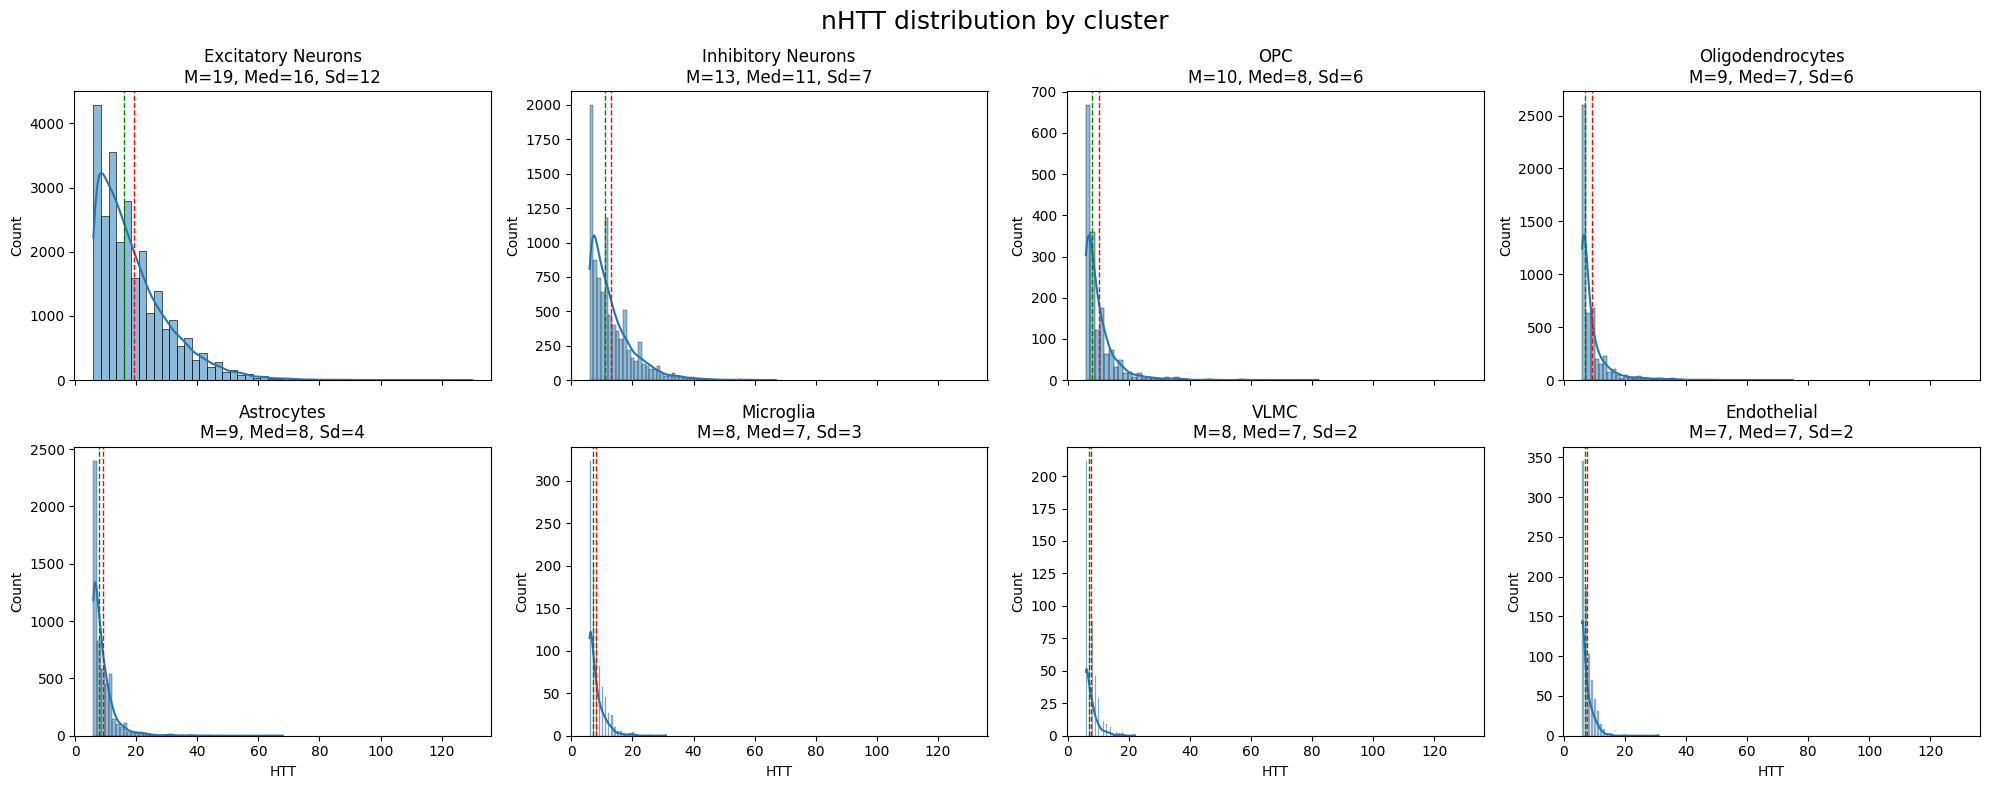

In [20]:
cluster_order = (
    HTT_5.obs
    .groupby('cluster_general')['nHTT']
    .mean()
    .sort_values(ascending=False)  # highest median first
    .index
)

ocluster = cluster_order
n_clusters = len(ocluster)

ncols = 4
nrows = math.ceil(n_clusters / ncols)

fig, axes = plt.subplots(nrows,ncols,figsize=(5*ncols, 4*nrows),sharex=True,)
axes = np.array(axes).flatten()

for i, cl in enumerate(ocluster):
    ax = axes[i]
    s_HTT5 = HTT_5[HTT_5.obs['cluster_general'] == cl]
    data = pd.DataFrame({
        'HTT': s_HTT5.obs['nHTT']
    })

    mean_value = data['HTT'].mean()
    median_value = data['HTT'].median()
    sd = data['HTT'].std()

    sns.histplot( data=data,x='HTT',bins=50,kde=True,ax=ax)
    ax.axvline(mean_value,color='red',linestyle='--',linewidth=1)
    ax.axvline(median_value,color='green',linestyle='--', linewidth=1)
    ax.set_title(f'{cl}\nM={mean_value:.0f}, Med={median_value:.0f}, Sd={sd:.0f}', fontsize=12)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('nHTT distribution by cluster', fontsize=18)
plt.tight_layout()
plt.savefig('Figures/HTTHist_All.png')
plt.show()

/var/folders/7p/t1dymgvj689ffh7fbygsmbzc0000gp/T/ipykernel_55460/1265161563.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Neurons5.obs
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: i

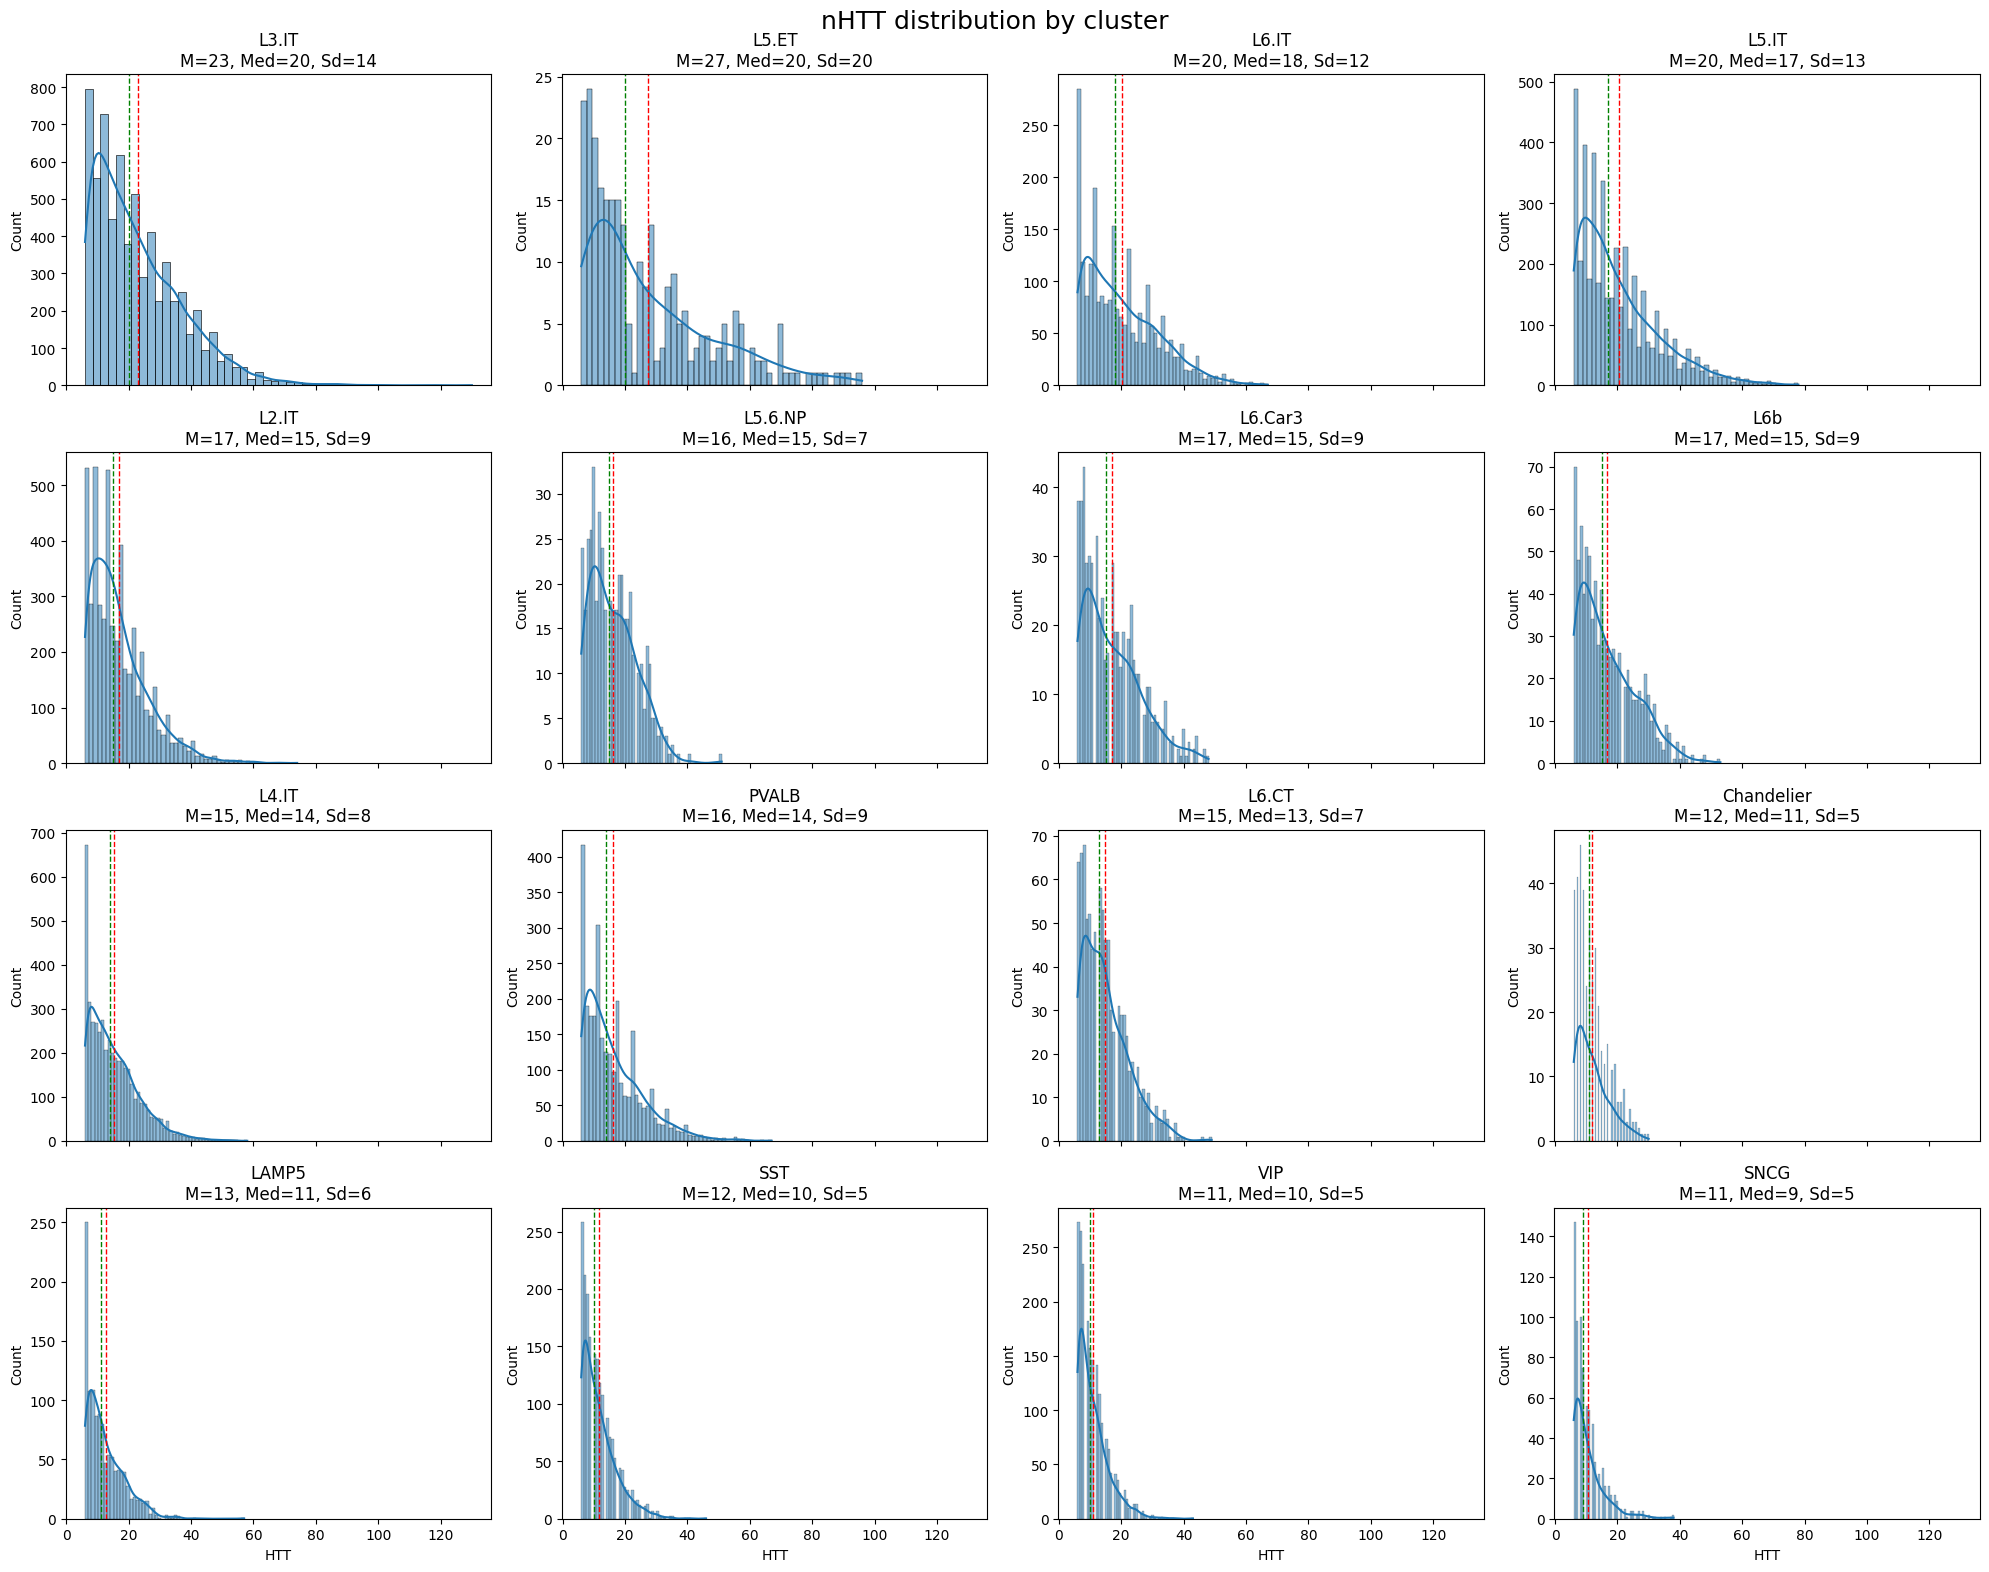

In [21]:

cluster_order = (
    Neurons5.obs
    .groupby('cluster_names')['nHTT']
    .median()
    .sort_values(ascending=False)  # highest median first
    .index
)

ecluster = cluster_order
n_clusters = len(ecluster)

ncols = 4
nrows = math.ceil(n_clusters / ncols)

fig, axes = plt.subplots(nrows,ncols,figsize=(5*ncols, 4*nrows),sharex=True,)
axes = np.array(axes).flatten()

for i, cl in enumerate(ecluster):
    ax = axes[i]
    s_neu5 = Neurons5[Neurons5.obs['cluster_names'] == cl]
    data = pd.DataFrame({
        'HTT': s_neu5.obs['nHTT']
    })

    mean_value = data['HTT'].mean()
    median_value = data['HTT'].median()
    sd = data['HTT'].std()

    sns.histplot( data=data,x='HTT',bins=50,kde=True,ax=ax)
    ax.axvline(mean_value,color='red',linestyle='--',linewidth=1)
    ax.axvline(median_value,color='green',linestyle='--', linewidth=1)
    ax.set_title(f'{cl}\nM={mean_value:.0f}, Med={median_value:.0f}, Sd={sd:.0f}', fontsize=12)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('nHTT distribution by cluster', fontsize=18)
plt.tight_layout()
plt.savefig('Figures/HTTHist_Exc.png')
plt.show()

In [22]:
##################################################
#### FIGURE 4D: Percent of cells with CAG<60
##################################################

In [23]:
data_df = HTT_5.obs[[ 'cluster_names','cluster_general','patient','CAG_mut']].copy()

data_df['Condition'] = '<50'
data_df.loc[(data_df['CAG_mut']>=50), 'Condition'] = '50-150'
data_df.loc[(data_df['CAG_mut']>=150), 'Condition'] = '150-250'
data_df.loc[(data_df['CAG_mut']>=250), 'Condition'] = '250-350'
data_df.loc[(data_df['CAG_mut']>=350), 'Condition'] = '350-450'
data_df.loc[(data_df['CAG_mut']>=450), 'Condition'] =  '>450'

In [24]:
# Count cells per cluster/condition/patient Major CL
condition_counts = (
    data_df
    .groupby(['patient', 'cluster_general', 'Condition'])
    .size()
    .unstack(fill_value=0)
)

total_counts = condition_counts.sum(axis=1)

percentages_patient = (condition_counts.T / total_counts).T * 100
percentages_patient = percentages_patient.reset_index() 
percentages_patient['HD'] = percentages_patient['patient'].str.startswith('H')
percentages_patient.to_csv('processed_data/CAG_bins_major_cl.csv')

/var/folders/7p/t1dymgvj689ffh7fbygsmbzc0000gp/T/ipykernel_55460/2414351574.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_df


In [25]:
# Count cells per cluster/condition/patient
condition_counts = (
    data_df
    .groupby(['patient', 'cluster_names', 'Condition'])
    .size()
    .unstack(fill_value=0)
)

total_counts = condition_counts.sum(axis=1)

percentages_patient = (condition_counts.T / total_counts).T * 100
percentages_patient = percentages_patient.reset_index() 
percentages_patient['HD'] = percentages_patient['patient'].str.startswith('H')
percentages_patient.to_csv('processed_data/CAG_bins.csv')

/var/folders/7p/t1dymgvj689ffh7fbygsmbzc0000gp/T/ipykernel_55460/3794852099.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_df


In [26]:
##################################################
#### SUPPLEMENTARY FIGURE 13B: Distribution of mutant CAG per cell by donor
##################################################

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seabor

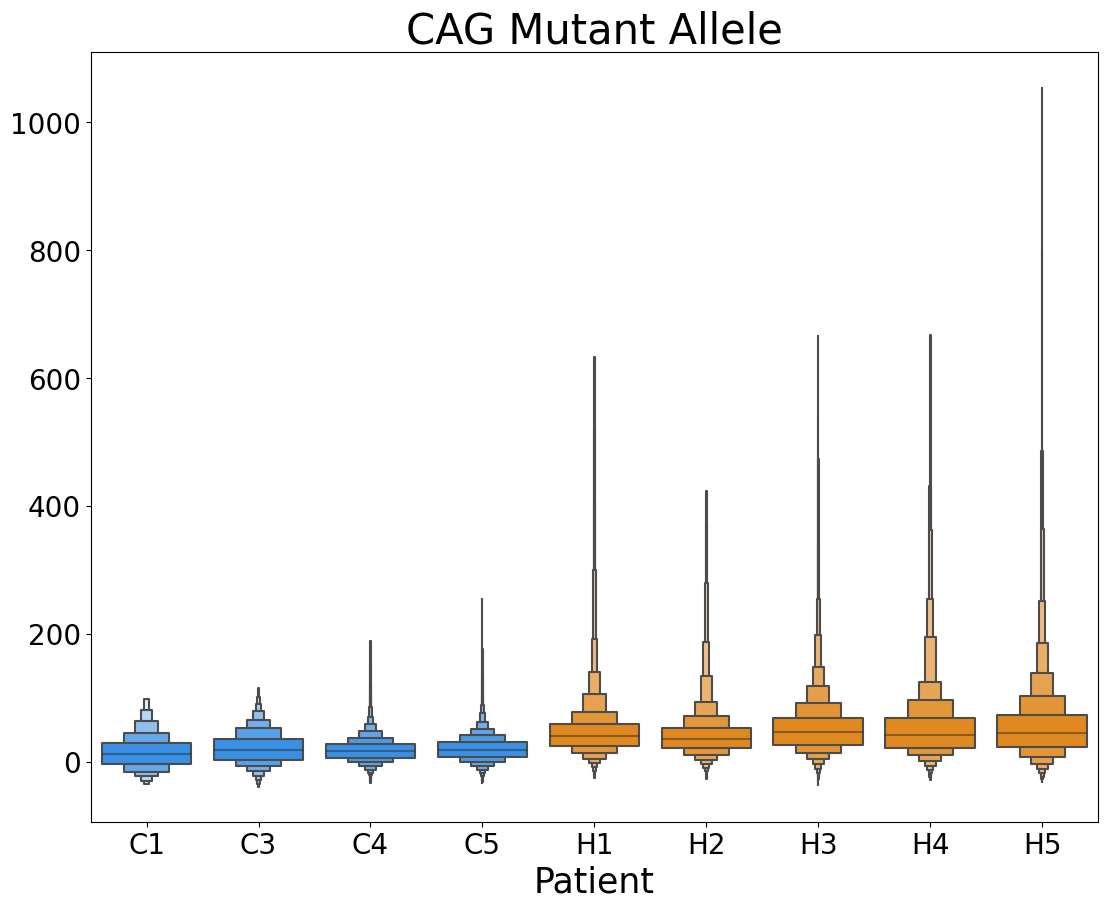

In [27]:
cmap = ['#1E90FF','#1E90FF','#1E90FF','#1E90FF','#FF8C00','#FF8C00','#FF8C00','#FF8C00','#FF8C00']

plt.figure(figsize=(13, 10))

sns.boxenplot(x='patient', y='CAG_mut', data=HTT_5.obs,palette=cmap, width=0.8,linewidth=1.5,showfliers=False)

plt.title('CAG Mutant Allele', fontsize=30)
plt.xticks (fontsize=20) 
plt.yticks(fontsize=20) 
plt.xlabel('Patient', fontsize=25)
plt.ylabel('',fontsize=30)
plt.grid(False)
plt.savefig('Figures/SF11B.pdf')

plt.show()

In [28]:
##################################################
#### SUPPLEMENTARY FIGURE 13C
##################################################

/var/folders/7p/t1dymgvj689ffh7fbygsmbzc0000gp/T/ipykernel_55460/1032911923.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for (patient, cluster) in data_df.groupby(['patient', 'cluster_general']):
/var/folders/7p/t1dymgvj689ffh7fbygsmbzc0000gp/T/ipykernel_55460/1032911923.py:28: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is depre

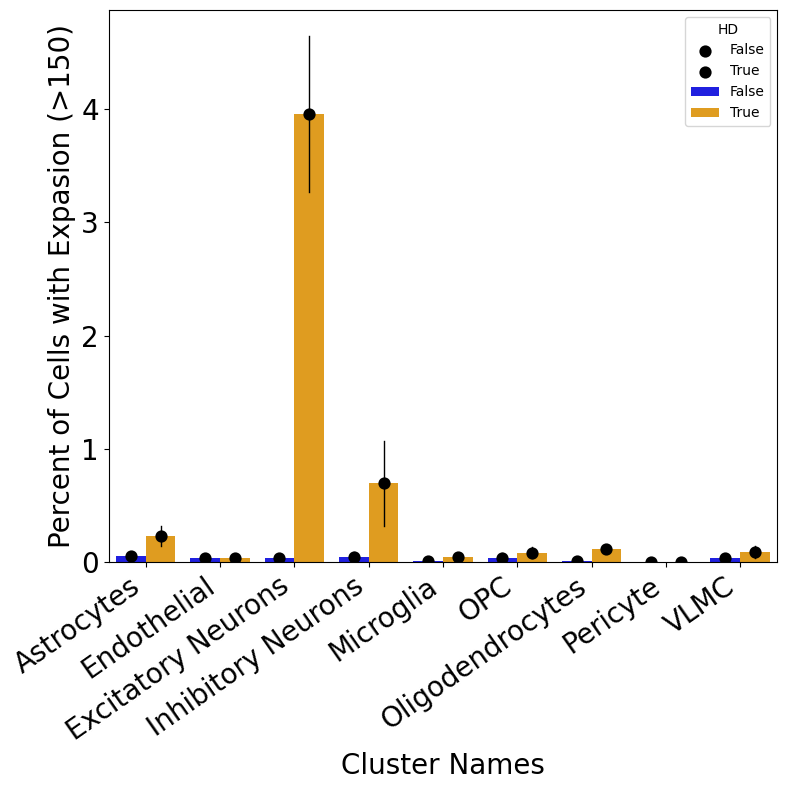

In [29]:
hd_palette = {'True': '#FFA500', 'False': '#0000FF'}
se_palette = {'True': 'black', 'False': 'black'}

data_df = adata.obs[['Expansion','patient', 'cluster_general','cluster_names', 'Agg', 'HD']].copy()
data_df['Expansion'] = data_df['Expansion'].fillna(False).astype('bool')

exp_percentages_all = []

for (patient, cluster) in data_df.groupby(['patient', 'cluster_general']):
    total_cells = len(cluster)
    percent_with_exp = np.sum(cluster['Expansion']) / total_cells * 100
    
    exp_percentages_all.append({
        'patient': patient,
        'cluster_general': cluster['cluster_general'].iloc[0],
        'percent_with_exp': percent_with_exp,
        'HD': str(cluster['HD'].iloc[0])  # Convert HD status to string
    })

exp_all_percent_df = pd.DataFrame(exp_percentages_all)

exp_stats_all = exp_all_percent_df.groupby(['cluster_general', 'HD']).agg(
    mean_with_exp=('percent_with_exp', 'mean')
).reset_index()

plt.figure(figsize=(8, 8))

ax = sns.barplot(
    x='cluster_general', y='mean_with_exp', hue='HD',
    data=exp_stats_all, palette=hd_palette, ci=None, dodge=True
)

sns.pointplot(
    x='cluster_general', y='percent_with_exp',
    data=exp_all_percent_df, palette=se_palette, hue='HD', dodge=0.4, join=False, errorbar=('se', 1),  errwidth=1
)

plt.xlabel('Cluster Names', fontsize=20)
plt.ylabel('Percent of Cells with Expasion (>150)', fontsize=20)
plt.xticks(rotation=35, fontsize=20, ha='right')
plt.yticks(fontsize=20)

plt.tight_layout()
plt.savefig('Figures/SF11C.pdf')
plt.show()

In [30]:
##################################################
#### SUPPLEMENTARY FIGURE 13D
##################################################

In [31]:
cluster_order =['L2.IT', 'L3.IT', 'L5.IT', 'L4.IT', 'L5.ET', 'L5.6.NP', 'L6.IT', 'L6.CT', 'L6.Car3', 'L6b','Chandelier', 'LAMP5', 'PVALB', 'SNCG', 'SST', 'VIP' ]

/var/folders/7p/t1dymgvj689ffh7fbygsmbzc0000gp/T/ipykernel_55460/639636146.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for (patient, cluster) in data_df.groupby(['patient', 'cluster_names']):
/var/folders/7p/t1dymgvj689ffh7fbygsmbzc0000gp/T/ipykernel_55460/639636146.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = percent_df_CAG.groupby(['cluster_names', 'HD'])
/var/folders/7p/t1dymgvj689ffh7fbygsmbzc0000gp/T/ipykernel_55460/639636146.py:27: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(
/Users/Olatz/anaconda3/envs/napari/

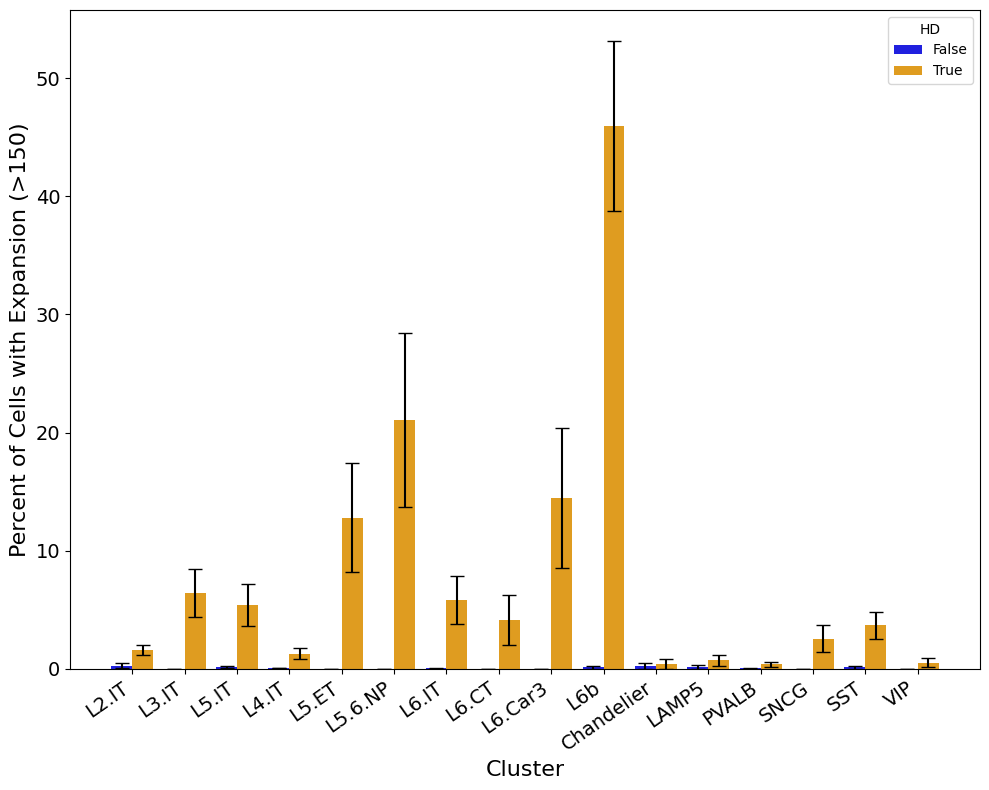

In [32]:
data_df = Neurons5.obs[['Expansion','patient', 'cluster_general','cluster_names', 'HD']].copy()
data_df['Expansion'] = data_df['Expansion'].fillna(False).astype(bool)
data_df['HD'] = data_df['HD'].astype(str)

percentages = []

for (patient, cluster) in data_df.groupby(['patient', 'cluster_names']):
    total_cells = len(cluster)
    percent_with_exp = np.sum(cluster['Expansion']) / total_cells * 100
    percentages.append({
        'patient': patient,
        'cluster_names': cluster['cluster_names'].iloc[0],
        'percent_with_exp': percent_with_exp,
        'HD': cluster['HD'].iloc[0]
    })

percent_df_CAG = pd.DataFrame(percentages)
percent_df_CAG['cluster_names'] = pd.Categorical(percent_df_CAG['cluster_names'], categories=cluster_order, ordered=True)

grouped = percent_df_CAG.groupby(['cluster_names', 'HD'])
summary_df = grouped['percent_with_exp'].agg(['mean', 'sem']).reset_index()
summary_df.rename(columns={'mean': 'mean_with_exp', 'sem': 'se_with_exp'}, inplace=True)

plt.figure(figsize=(10, 8))
order = cluster_order

ax = sns.barplot(
    data=summary_df,
    x='cluster_names', y='mean_with_exp', hue='HD',
    palette=hd_palette, order=order, dodge=True, ci=None
)

hue_offset = {'False': -0.2, 'True': 0.2} 
for i, cluster in enumerate(order):
    for hd in ['False', 'True']:
        subset = summary_df[(summary_df['cluster_names'] == cluster) & (summary_df['HD'] == hd)]
        if not subset.empty:
            y = subset['mean_with_exp'].values[0]
            yerr = subset['se_with_exp'].values[0]
            x = i + hue_offset[hd]
            ax.errorbar(x, y, yerr=yerr, fmt='none', ecolor='black', capsize=5, linewidth=1.5)

plt.xlabel('Cluster', fontsize=16)
plt.ylabel('Percent of Cells with Expansion (>150)', fontsize=16)
plt.xticks(rotation=35, ha='right', fontsize=14)
plt.yticks(fontsize=14)
plt.legend(title='HD')
plt.tight_layout()
plt.savefig('Figures/SF11D.pdf')
plt.show()


In [33]:
summary_df_hd=summary_df[summary_df['HD']=='True'].copy()

In [34]:
##################################################
#### FIGURE 4E: CAG bins in HD Neuronal clusters
##################################################

In [35]:
Neurons5_HD = Neurons5[Neurons5.obs['HD']==True].copy()
Neurons5_CTL= Neurons5[Neurons5.obs['HD']==False].copy()

In [36]:
cluster_order = [ "L2.IT", "L3.IT","L4.IT",'L5.IT', 'L5.ET', "L5.6.NP",'L6.IT', 'L6.Car3', "L6.CT",'L6b',"Chandelier","LAMP5","PVALB", "SNCG",'VIP', "SST" ]

In [37]:
Neurons5.obs['cluster_names'] = pd.Categorical(
    Neurons5.obs['cluster_names'],
    categories=cluster_order,
    ordered=True
)

In [38]:
upatient = Neurons5_HD.obs['patient'].unique()

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/categorical

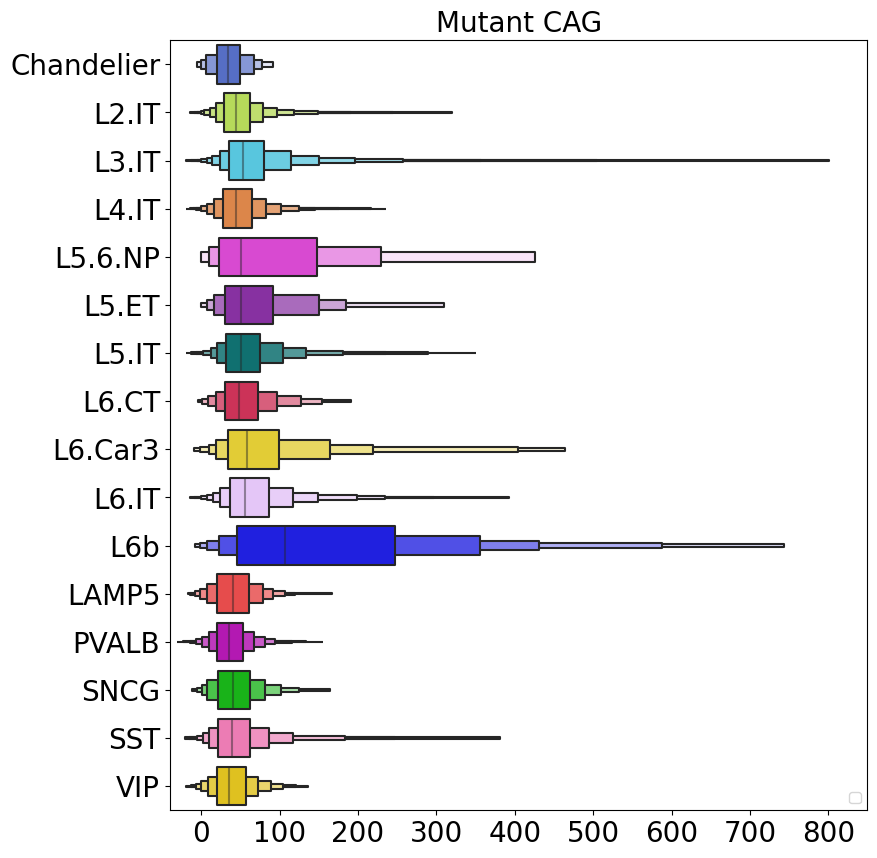

In [39]:
cmap = ['#4363d8', '#bfef45', #L2, L3, 
    '#42d4f4', # L4 '#FF6347','#FF6347','#FF6347', #L4.5,
    '#f58231', '#f032e6','#911eb4', # , L5, L5ET L56NP,
    '#008080','#e6194B', '#ffe119',  '#e6beff', # L6, L6Car3,  L6CT, L6b 
          '#0000ff', '#ff3333',  '#cc00cc',  #Chandelier LAMP PVALB
    '#00cc00', '#FF69B4',  '#FFD700',  #SNCG, VIP SST,  
       ]

plt.figure(figsize=(9, 10))


sns.boxenplot(data=Neurons5_HD.obs, x='CAG_mut',y='cluster_names', palette=cmap , showfliers=False)
plt.title(f'Mutant CAG', fontsize=20)
plt.xlabel('', fontsize=18)
plt.ylabel('', fontsize=18)
plt.xticks(fontsize=20)
plt.yticks( fontsize=20)
plt.xlim(-40,850)
plt.legend(loc='lower right')

plt.savefig('Figures/F4E.pdf')
plt.show()

In [40]:
##################################################
#### FIGURE 4F: CAG distributions in HD Neuronal clusters
##################################################

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in 

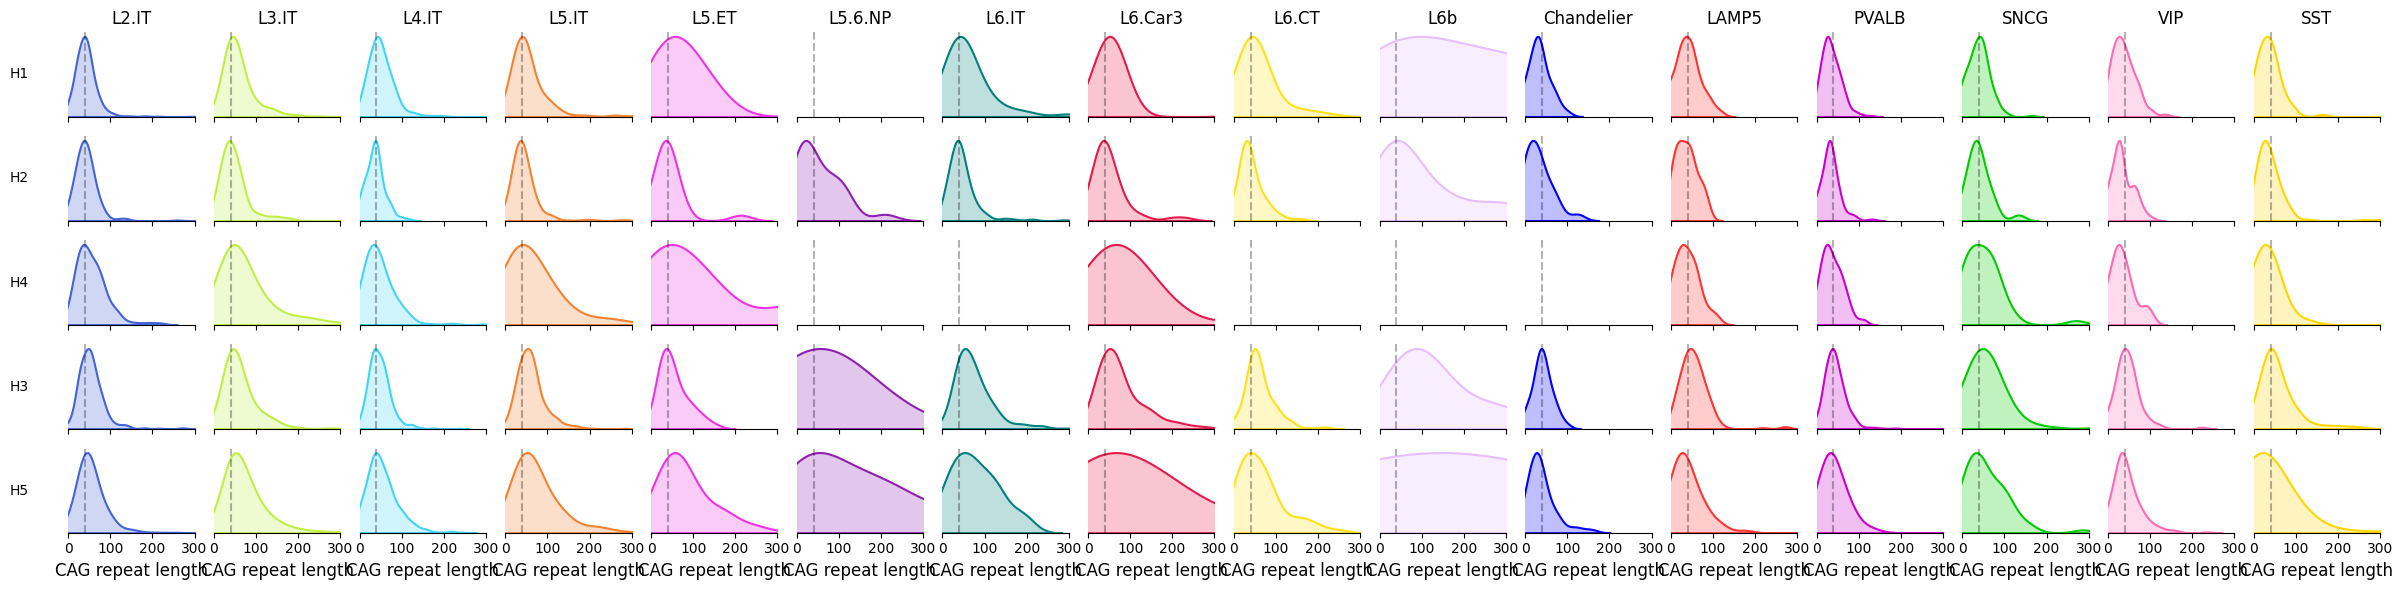

In [41]:
cmap = ['#4363d8', '#bfef45', #L2, L3, 
    '#42d4f4', # L4 '#FF6347','#FF6347','#FF6347', #L4.5,
    '#f58231','#f032e6', '#911eb4', # , L5, L5ET L56NP,
    '#008080','#e6194B','#ffe119',   '#e6beff', # L6, L6Car3,  L6CT, L6b 
          '#0000ff', '#ff3333',  '#cc00cc',  #Chandelier LAMP PVALB
    '#00cc00', '#FF69B4',  '#FFD700',  #SNCG, VIP SST,  
       ]

patients = upatient
clusters = cluster_order

n_cols = len(clusters)
n_rows= len(patients)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(1.5*n_cols, 1.2*n_rows),
    sharex=True,
    sharey=False
)

# handle edge cases
if n_rows == 1:
    axes = [axes]
if n_cols == 1:
    axes = [[ax] for ax in axes]

for row, pt in enumerate(patients):
    for col, (cl, color) in enumerate(zip(clusters, cmap)):
        
        ax = axes[row][col]
        
        subset = Neurons5_HD.obs[
            (Neurons5_HD.obs['patient'] == pt) &
            (Neurons5_HD.obs['cluster_names'] == cl)
        ]
        
        if len(subset) > 10:  # avoid noisy tiny clusters
            sns.kdeplot(
                data=subset,
                x='CAG_mut',
                ax=ax,
                color=color,
                linewidth=1.5,
                fill=True
            )
            
        ax.axvline(40, linestyle='--', color='black', alpha=0.3)
        
        # row labels (clusters)
        if col == 0:
            ax.set_ylabel(pt, rotation=0, labelpad=35, fontsize=10, va='center')
        else:
            ax.set_ylabel('')
        
        # column titles (patients)
        if row == 0:
            ax.set_title(cl, fontsize=12)
        
        # clean look
        ax.set_yticks([])
        ax.set_xlabel('')
        sns.despine(ax=ax, left=True)

# bottom x-axis only
for ax in axes[-1]:
    ax.set_xlabel('CAG repeat length', fontsize=12)

plt.xlim(0, 300)
plt.tight_layout()
plt.savefig('Figures/SF11F.pdf')
plt.show()

In [42]:
##################################################
#### SUPPLEMENTARY FIGURE 13G: Instability Index
##################################################

In [43]:
inh_allele = {
    "H1": 46, "H2": 45, "H3": 57, "H4": 45, "H5": 55
}

In [44]:
results = []

for pt in upatient:

    pt_obs = Neurons5_HD.obs[Neurons5_HD.obs['patient'] == pt]

    baseline = inh_allele[pt]

    for cl, group in pt_obs.groupby('cluster_names'):

        cag = group['CAG_mut'].dropna()

        if len(cag) < 10:
            continue

        expansions = cag[cag > baseline]

        delta = cag - baseline
        sei = delta.clip(lower=0).sum() / len(cag)

        results.append({
            'patient': pt,
            'cluster': cl,
            'SEI': sei
        })

df_sei = pd.DataFrame(results)
df_sei.to_csv('processed_data/CAG_sei.csv')

/var/folders/7p/t1dymgvj689ffh7fbygsmbzc0000gp/T/ipykernel_55460/4195562465.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for cl, group in pt_obs.groupby('cluster_names'):


In [45]:
df_sei

,patient,cluster,SEI
0,H1,Chandelier,5.297523
1,H1,L2.IT,8.150635
2,H1,L3.IT,21.585141
3,H1,L4.IT,13.711624
4,H1,L5.ET,47.657386
...,...,...,...
69,H5,LAMP5,10.902796
70,H5,PVALB,10.858909
71,H5,SNCG,20.607314
72,H5,SST,33.296686


In [46]:
cluster_mean = (
    df_sei.groupby('cluster')['SEI']
          .mean()
          .sort_values(ascending=False)
)
cluster_mean

cluster
L6b           184.612981
L5.6.NP        77.170568
L6.Car3        52.991355
L5.ET          38.985939
L6.IT          27.307553
L3.IT          27.104559
L5.IT          24.125840
L6.CT          19.109120
SST            16.692536
SNCG           16.219591
L2.IT          12.044490
L4.IT          10.937919
LAMP5           9.166956
VIP             7.260826
PVALB           6.432923
Chandelier      5.905795
Name: SEI, dtype: float64

In [47]:
##################################################
#### SUPPLEMENTARY FIGURE 13E: CAG length bins in HD cortex
##################################################

/var/folders/7p/t1dymgvj689ffh7fbygsmbzc0000gp/T/ipykernel_55460/2230461987.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  condition_counts = data_df.groupby(['cluster_names', 'Condition']).size().unstack(fill_value=0)


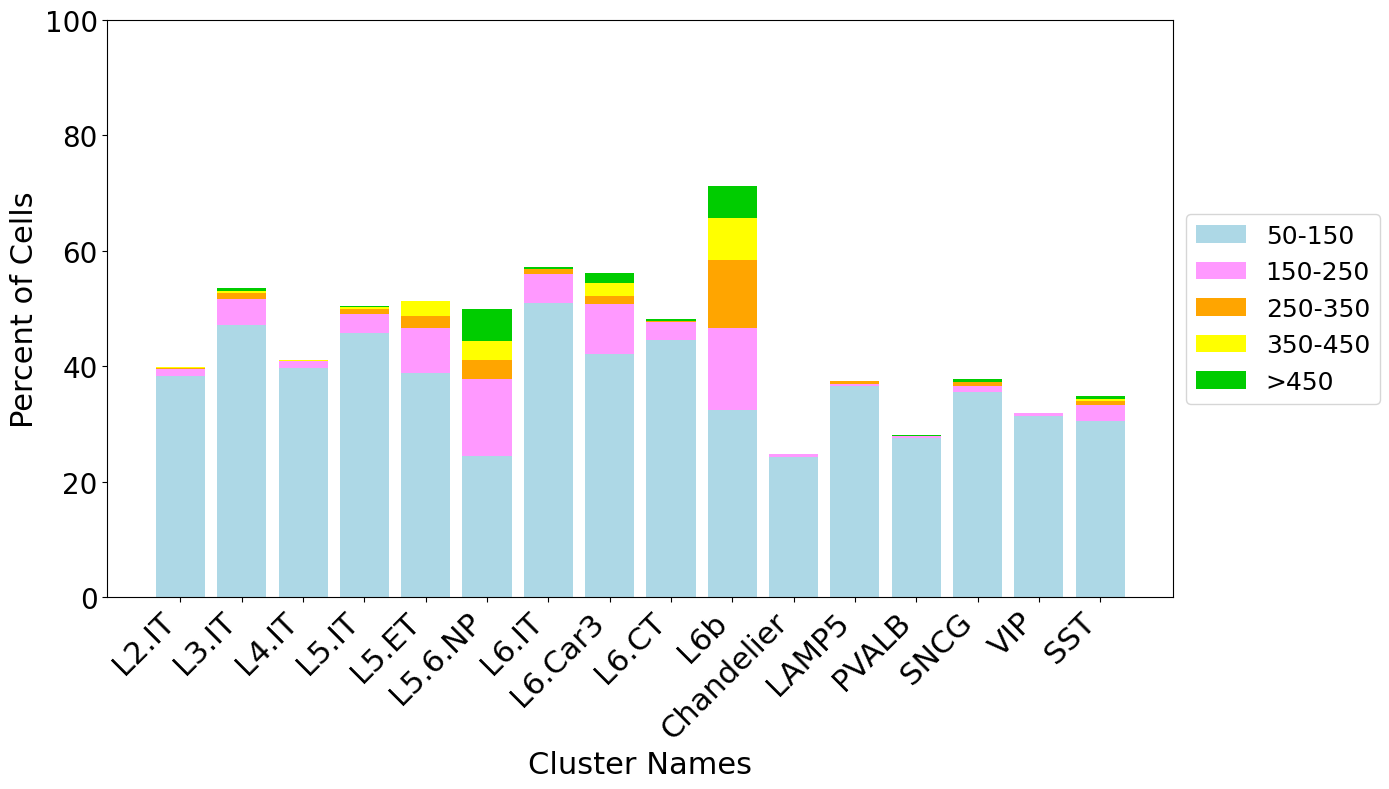

In [48]:
data_df = Neurons5_HD.obs[[ 'cluster_names','patient','CAG_mut']].copy()

data_df['Condition'] = '<50'  # Default
data_df.loc[(data_df['CAG_mut']>=50), 'Condition'] = '50-150'
data_df.loc[(data_df['CAG_mut']>=150), 'Condition'] = '150-250'
data_df.loc[(data_df['CAG_mut']>=250), 'Condition'] = '250-350'
data_df.loc[(data_df['CAG_mut']>=350), 'Condition'] = '350-450'
data_df.loc[(data_df['CAG_mut']>=450), 'Condition'] =  '>450'

condition_counts = data_df.groupby(['cluster_names', 'Condition']).size().unstack(fill_value=0)
total_counts = condition_counts.sum(axis=1)
percentages = (condition_counts.T / total_counts).T * 100

percentages = percentages.loc[cluster_order]

clusters = percentages.index
conditions = ['50-150', '150-250', '250-350', '350-450', '>450']
bar_width = 0.8
index = np.arange(len(clusters))

colors = {
    '50-150': 'lightblue',
    '150-250': '#ff99ff',
    '250-350': 'orange',
    '350-450':'yellow',
      '>450':'#00cc00'
}

plt.figure(figsize=(14, 8))

bottoms = np.zeros(len(clusters))
for condition in conditions:
    if condition in percentages.columns:
        plt.bar(index, percentages[condition], bar_width,
                bottom=bottoms, label=condition, color=colors[condition])
        bottoms += percentages[condition]
        
plt.title('', fontsize=25)
plt.xlabel('Cluster Names', fontsize=22)
plt.ylabel('Percent of Cells', fontsize=22)
plt.xticks(index, clusters, fontsize=22, rotation=45, ha='right')
plt.yticks(fontsize=20)
plt.ylim(0,100)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=18)
plt.tight_layout()
plt.savefig('Figures/SF11E.pdf')
plt.show()

In [49]:
##################################################
#### FIGURE 4G: CAG >450 in HD Neuronal clusters
##################################################

In [50]:
condition_counts = (
    data_df
    .groupby(['patient', 'cluster_names', 'Condition'])
    .size()
    .unstack(fill_value=0)
)

total_counts = condition_counts.sum(axis=1)
percentages_patient = (condition_counts.T / total_counts).T * 100

/var/folders/7p/t1dymgvj689ffh7fbygsmbzc0000gp/T/ipykernel_55460/3848457342.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_df


/var/folders/7p/t1dymgvj689ffh7fbygsmbzc0000gp/T/ipykernel_55460/1277849036.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  percentages_mean = percentages_patient.groupby('cluster_names').mean()
/var/folders/7p/t1dymgvj689ffh7fbygsmbzc0000gp/T/ipykernel_55460/1277849036.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  percentages_sem = percentages_patient.groupby('cluster_names').sem()
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


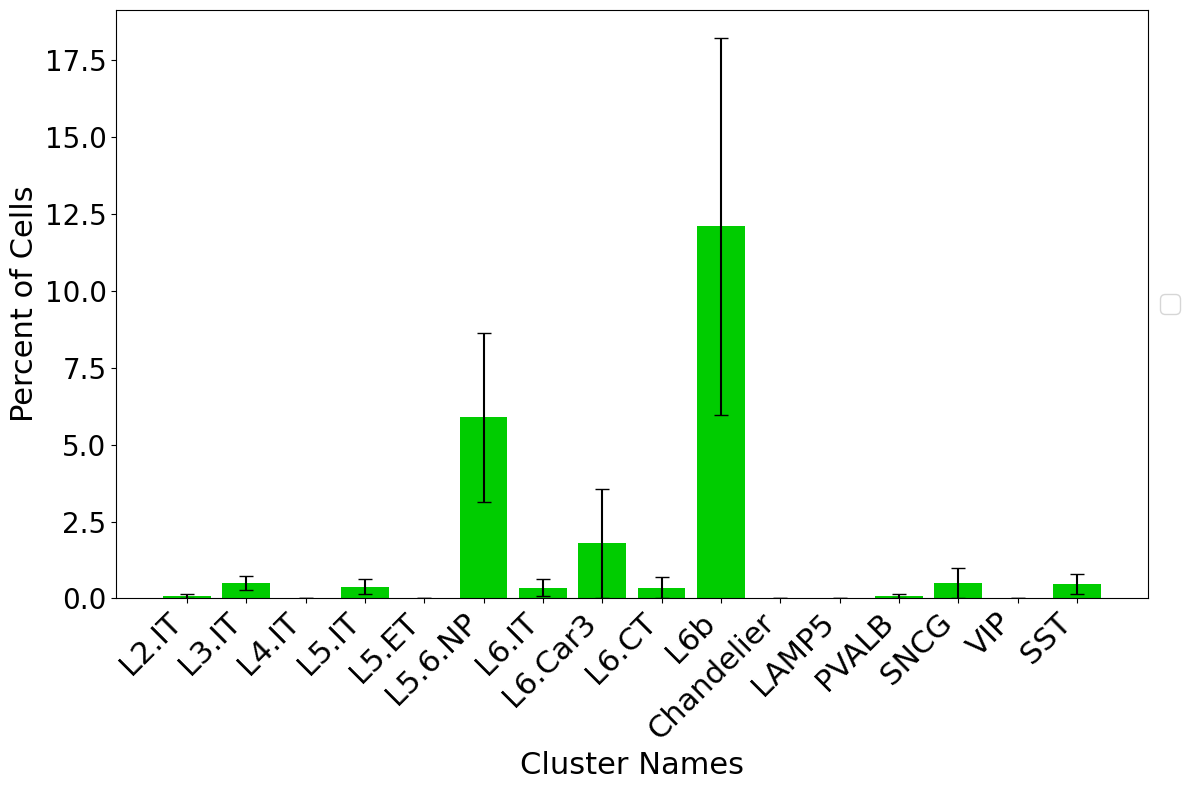

In [51]:
percentages_mean = percentages_patient.groupby('cluster_names').mean()
percentages_sem = percentages_patient.groupby('cluster_names').sem()

percentages_mean = percentages_mean.reindex(cluster_order)
percentages_sem  = percentages_sem.reindex(cluster_order)

clusters = percentages_mean.index
condition = '>450'

means = percentages_mean[condition]
sems  = percentages_sem[condition]

colors = {
    '50-150': 'lightblue',
    '150-250': '#ff99ff',
    '250-350': 'orange',
    '350-450':'yellow',
      '>450':'#00cc00'
}


plt.figure(figsize=(12, 8))
plt.bar(clusters, means, yerr=sems, 
        color=colors[condition], capsize=5)

plt.title('', fontsize=25)
plt.xlabel('Cluster Names', fontsize=22)
plt.ylabel('Percent of Cells', fontsize=22)
plt.xticks(rotation=45, ha='right', fontsize=22)
plt.yticks(fontsize=20)
#plt.ylim(0, 20)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=18)

plt.tight_layout()
#plt.savefig('Figures/F4F.pdf')
plt.show()



In [52]:
##################################################
#### SUPPLEMENTARY FIGURE 13F: CAG length bins in CTL cortex
##################################################

/var/folders/7p/t1dymgvj689ffh7fbygsmbzc0000gp/T/ipykernel_55460/993200881.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  condition_counts = data_df.groupby(['cluster_names', 'Condition']).size().unstack(fill_value=0)


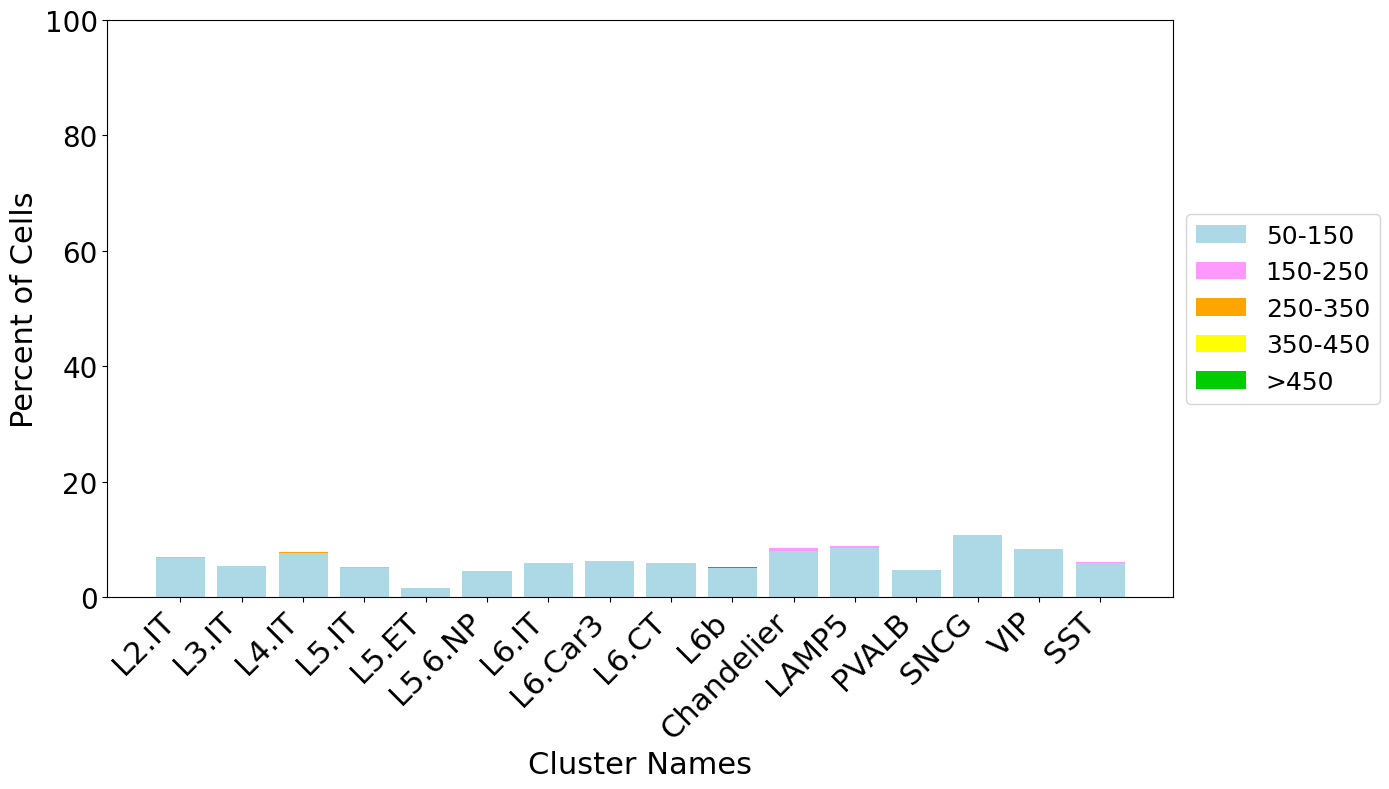

In [53]:
data_df = Neurons5_CTL.obs[[ 'cluster_names','patient','CAG_mut']].copy()

data_df['Condition'] = '<50'  # Default
data_df.loc[(data_df['CAG_mut']>=50), 'Condition'] = '50-150'
data_df.loc[(data_df['CAG_mut']>=150), 'Condition'] = '150-250'
data_df.loc[(data_df['CAG_mut']>=250), 'Condition'] = '250-350'
data_df.loc[(data_df['CAG_mut']>=350), 'Condition'] = '350-450'
data_df.loc[(data_df['CAG_mut']>=450), 'Condition'] =  '>450'

condition_counts = data_df.groupby(['cluster_names', 'Condition']).size().unstack(fill_value=0)
total_counts = condition_counts.sum(axis=1)
percentages_ctl = (condition_counts.T / total_counts).T * 100

percentages_ctl = percentages_ctl.loc[cluster_order]

clusters = percentages_ctl.index
bar_width = 0.8
index = np.arange(len(clusters))


plt.figure(figsize=(14, 8))

bottoms = np.zeros(len(clusters))
for condition in conditions:
    if condition in percentages_ctl.columns:
        plt.bar(index, percentages_ctl[condition], bar_width,
                bottom=bottoms, label=condition, color=colors[condition])
        bottoms += percentages_ctl[condition]
        
plt.title('', fontsize=25)
plt.xlabel('Cluster Names', fontsize=22)
plt.ylabel('Percent of Cells', fontsize=22)
plt.ylim(0,100)
plt.xticks(index, clusters, fontsize=22, rotation=45, ha='right')
plt.yticks(fontsize=20)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=18)
plt.tight_layout()
plt.savefig('Figures/SF11F.pdf')
plt.show()

In [54]:
##################################################
#### SUPPLEMENTARY FIGURES 13H-I: CAG expansion vs Excitatory Neuron loss
##################################################

In [55]:
percent_lost_df = {
    'Cluster': ['L2.IT', 'L3.IT', 'L5.IT', 'L4.IT', 'L5.ET', 'L5.6.NP', 'L6.IT', 'L6.CT', 'L6.Car3', 'L6b'],
    'Percent Lost': [38.965629, 7.597639, 21.390964, 44.542414, 9.159061, 84.112792, 24.816347, 42.304075, 2.011352, 53.409478]
}

percent_lost_df = pd.DataFrame(percent_lost_df)
percent_lost_df.set_index('Cluster', inplace=True)

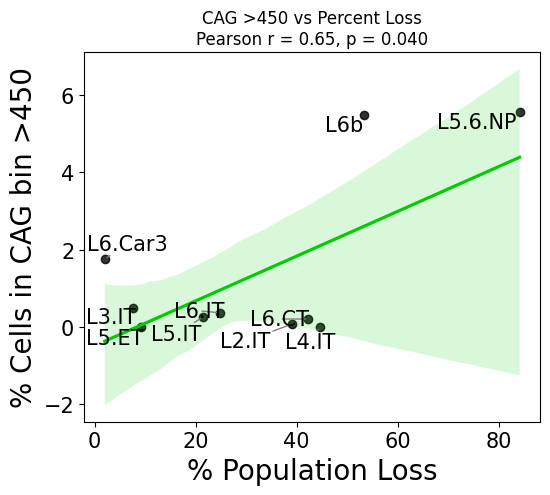

In [56]:
from scipy.stats import spearmanr
merged = percentages.merge(percent_lost_df, left_index=True, right_index=True)

pr, pp = pearsonr(merged['>450'], merged['Percent Lost'])


plt.figure(figsize=(5.5, 5))
sns.regplot(data=merged, y='>450', x='Percent Lost', scatter_kws={'color': 'black'}, line_kws={'color': '#00cc00'})

texts = []
for i, row in merged.iterrows():
    texts.append(plt.text( row['Percent Lost'],row['>450'], i, fontsize=15))
adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray'))

plt.title(f'CAG >450 vs Percent Loss\nPearson r = {pr:.2f}, p = {pp:.3f}')
plt.ylabel(f'% Cells in CAG bin >450', size=20)
plt.xlabel('% Population Loss', size=20)
plt.tight_layout()
plt.xticks(size=15)
plt.yticks(size=15)
plt.savefig('Figures/F4G.pdf')
plt.show()

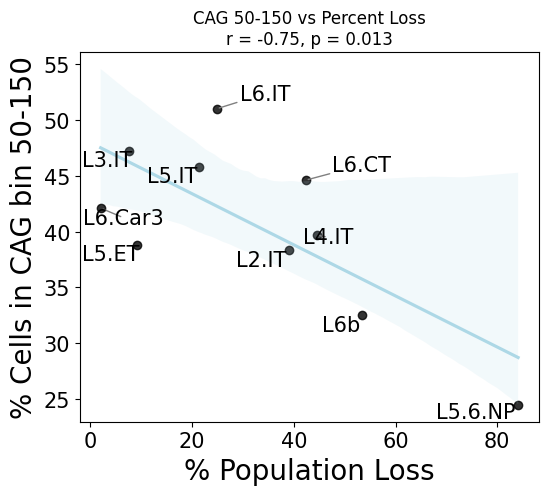

In [57]:
r, p = pearsonr(merged['50-150'], merged['Percent Lost'])

plt.figure(figsize=(5.5, 5))
sns.regplot(data=merged, y='50-150', x='Percent Lost', scatter_kws={'color': 'black'}, line_kws={'color': 'lightblue'})

texts = []
for i, row in merged.iterrows():
    texts.append(plt.text( row['Percent Lost'],row['50-150'], i, fontsize=15))
adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray'))

plt.title(f'CAG 50-150 vs Percent Loss\nr = {r:.2f}, p = {p:.3f}')
plt.ylabel(f'% Cells in CAG bin 50-150', size=20)
plt.xlabel('% Population Loss', size=20)
plt.tight_layout()
plt.xticks(size=15)
plt.yticks(size=15)
plt.savefig('Figures/F4I.pdf')
plt.show()

In [58]:
##################################################
#### SUPPLEMENTARY FIGURES 13J-K: CAG expansion vs Inhibitory Neuron loss
##################################################

In [59]:
percent_lost_df_inh = {
    'cluster_names': ['Chandelier', 'LAMP5', 'PVALB', 'SNCG', 'SST', 'VIP' ],
    'Percent Lost': [55.550050,7.380457, 14.008406,  -1.760563,   51.870968, 4.372169 ]
}

percent_lost_df_inh = pd.DataFrame(percent_lost_df_inh)
percent_lost_df_inh.set_index('cluster_names', inplace=True)

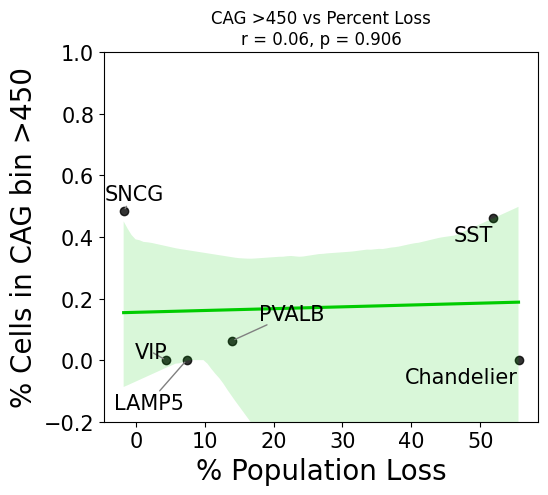

In [60]:
merged = percentages.merge(percent_lost_df_inh, left_index=True, right_index=True)

r, p = pearsonr(merged['>450'], merged['Percent Lost'])

plt.figure(figsize=(5.5, 5))
sns.regplot(data=merged, y='>450', x='Percent Lost', scatter_kws={'color': 'black'}, line_kws={'color': '#00cc00'})

texts = []
for i, row in merged.iterrows():
    texts.append(plt.text( row['Percent Lost'],row['>450'], i, fontsize=15))
adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray'))

plt.title(f'CAG >450 vs Percent Loss\nr = {r:.2f}, p = {p:.3f}')
plt.ylabel(f'% Cells in CAG bin >450', size=20)
plt.xlabel('% Population Loss', size=20)
plt.tight_layout()
plt.ylim(-0.2,1)
plt.xticks(size=15)
plt.yticks(size=15)
plt.savefig('Figures/SF11G.pdf')
plt.show()

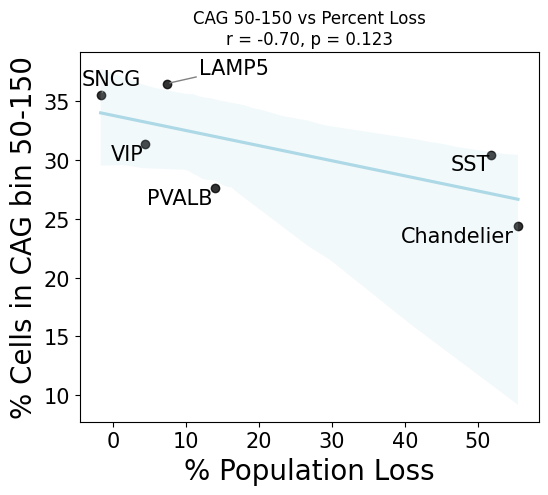

In [61]:
r, p = pearsonr(merged['50-150'], merged['Percent Lost'])

plt.figure(figsize=(5.5, 5))
sns.regplot(data=merged, y='50-150', x='Percent Lost', scatter_kws={'color': 'black'}, line_kws={'color': 'lightblue'})

texts = []
for i, row in merged.iterrows():
    texts.append(plt.text( row['Percent Lost'],row['50-150'], i, fontsize=15))
adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray'))

plt.title(f'CAG 50-150 vs Percent Loss\nr = {r:.2f}, p = {p:.3f}')
plt.ylabel(f'% Cells in CAG bin 50-150', size=20)
plt.xlabel('% Population Loss', size=20)
plt.tight_layout()
#plt.ylim(94,102)
plt.xticks(size=15)
plt.yticks(size=15)
plt.savefig('Figures/SF11H.pdf')

plt.show()

### DNA Repair Machinery expression per cluster vs CAG expanison and Neuronal loss

In [62]:
##################################################
#### SUPPLEMENTARY FIGURE 14AA: DNA repair machinery expression in Neuronal clusters
##################################################

In [63]:
Nuerons=adata[adata.obs['cluster_general'].isin(['Excitatory Neurons', 'Inhibitory Neurons'])].copy()
Neurons_CTL=Nuerons[Nuerons.obs['HD']==False].copy()
Neurons_HD=Nuerons[Nuerons.obs['HD']==True].copy()

In [64]:
cluster_order_neu = ["LAMP5", "SNCG",'VIP', "SST", "PVALB","Chandelier", "L2.IT", "L3.IT", "L4.IT",'L5.IT', 'L5.ET',"L5.6.NP",'L6.IT','L6.Car3', "L6.CT",'L6b' ]

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(

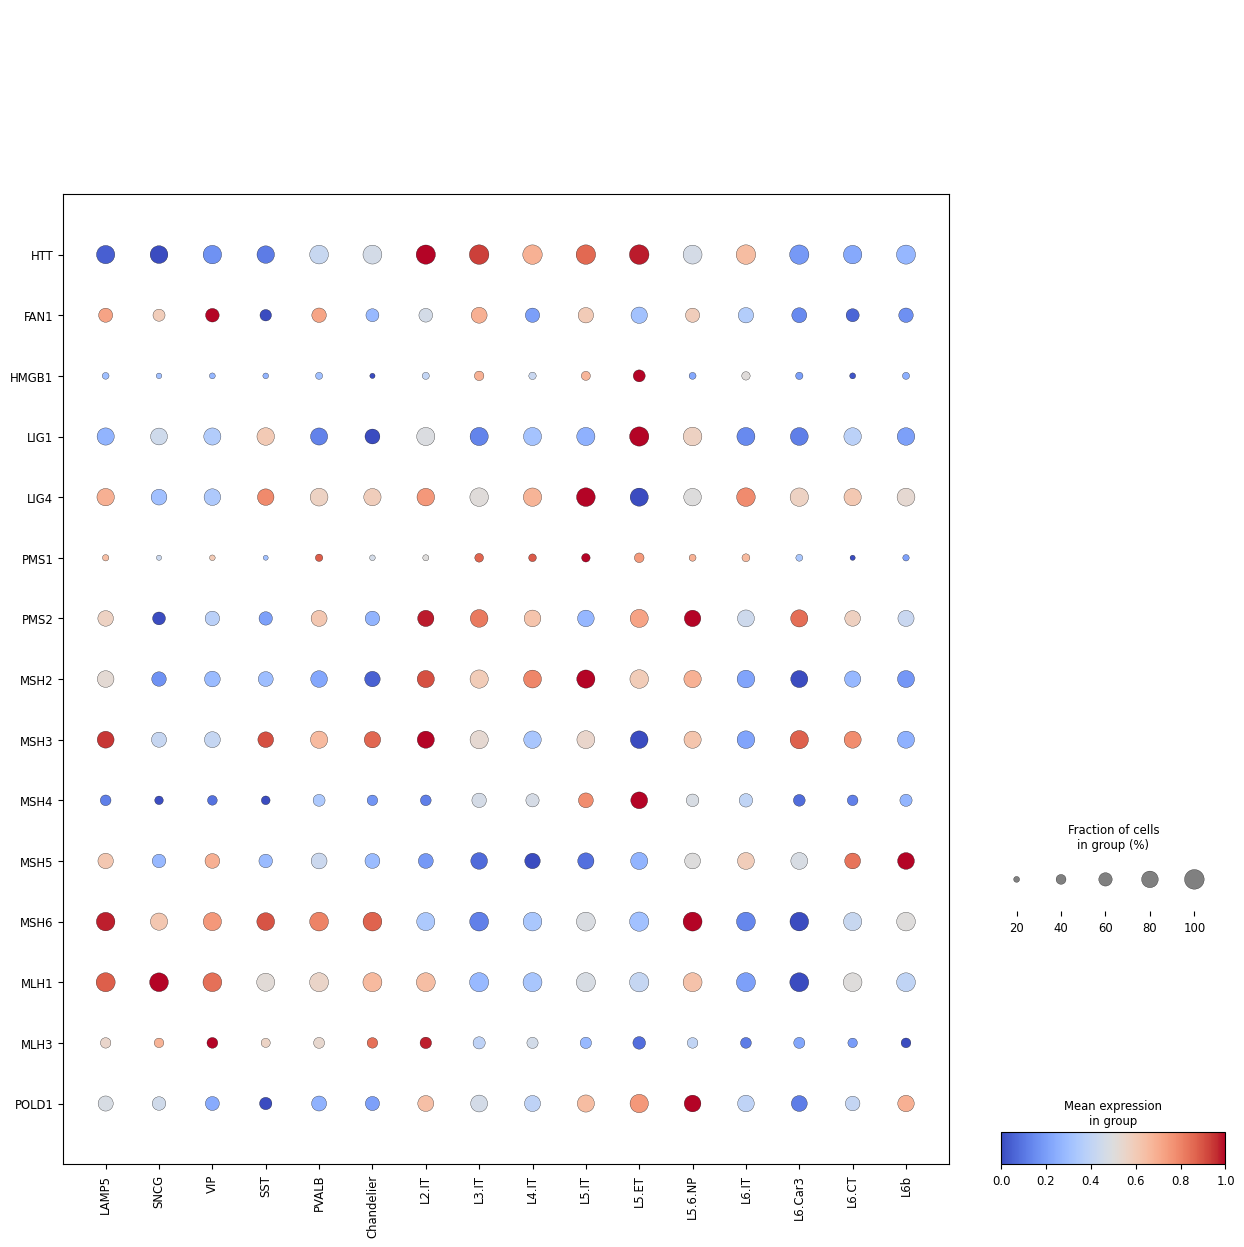

In [65]:
dna_repair = ['HTT','FAN1', 
'HMGB1', 'LIG1',  'LIG4', 'PMS1','PMS2','MSH2','MSH3','MSH4','MSH5', 
'MSH6', 'MLH1','MLH3','POLD1']

Neurons_CTL.obs['cluster_names'] = pd.Categorical(
    Neurons_CTL.obs['cluster_names'],
    categories=cluster_order_neu,
    ordered=True
)

fig, ax = plt.subplots(figsize=(15, 15), facecolor="white")

sc.pl.dotplot(
    Neurons_CTL,            
    var_names=dna_repair,  
    groupby='cluster_names', 
    standard_scale='var',    
    cmap='coolwarm',         
    ax=ax,                  
    swap_axes=True         
)

In [66]:
##################################################
####  FIGURES 4H: Expression of DNA repair genes
##################################################

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/scanpy/plotting/_matrixplot.py:143: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  values_df = self.obs_tidy.groupby(level=0).mean()


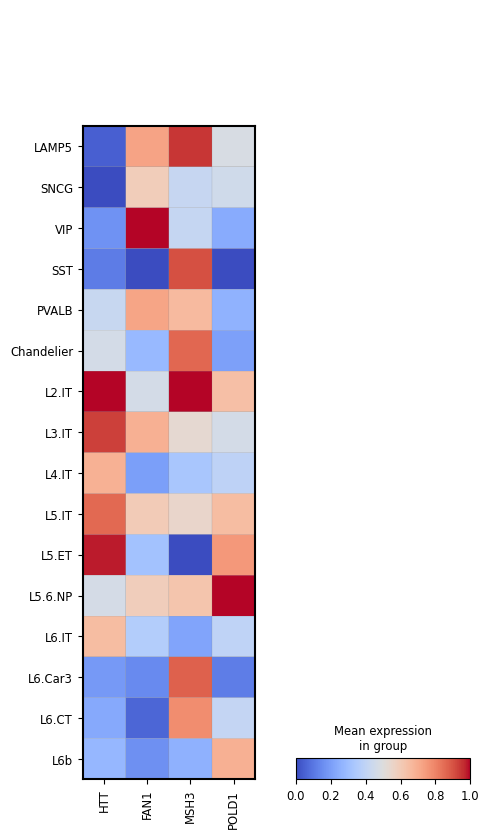

In [67]:
figure_dna_repair = ['HTT','FAN1', 'MSH3','POLD1']
fig, ax = plt.subplots(figsize=(5, 10), facecolor="white")
sc.pl.matrixplot(Neurons_CTL, figure_dna_repair, groupby='cluster_names', standard_scale='var', cmap='coolwarm', ax=ax)
ax.tick_params(axis="y", labelrotation=45)

In [68]:
##################################################
####  FIGURES 4I: DNA repair vs CAG
##################################################

In [69]:
dna_repair = ['HTT','FAN1', 
'HMGB1', 'LIG1',  'LIG4', 'PMS1','PMS2','MSH2','MSH3','MSH4','MSH5', 
'MSH6', 'MLH1','MLH3','POLD1']

In [70]:
Neurons_CTL

AnnData object with n_obs × n_vars = 29518 × 1128
    obs: 'volm', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'leiden', 'CAG', 'nHTT', 'vol_nuc', 'sample', 'HD', 'patient', 'batch', 'cluster_names', 'Agg', 'Agg_bright', 'Agg_vol', 'Agg_x', 'Agg_y', 'Agg_z', 'Agg_dist', 'cluster_general', 'lipo', 'm_gamma', 'v_gamma', 'm_h3k9', 'm_h3k27', 'CAG_length', 'CAG_mut', 'Expansion'
    obsm: 'X_pca', 'X_pca_harmony', 'X_raw', 'X_spatial', 'X_umap'

In [71]:
X_neu = Neurons_CTL.X  

expr_neu = pd.DataFrame(X_neu.toarray() if hasattr(X_neu, 'toarray') else X_neu,
                        index=Neurons_CTL.obs_names,
                        columns=Neurons_CTL.var_names)

expr_neu['cluster'] = Neurons_CTL.obs['cluster_names'].values
expr_df_neu = expr_neu.groupby('cluster')[dna_repair].mean()

/var/folders/7p/t1dymgvj689ffh7fbygsmbzc0000gp/T/ipykernel_55460/2896366037.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  expr_df_neu = expr_neu.groupby('cluster')[dna_repair].mean()


In [72]:
expr_df_neu

,HTT,FAN1,HMGB1,LIG1,LIG4,PMS1,PMS2,MSH2,MSH3,MSH4,MSH5,MSH6,MLH1,MLH3,POLD1
cluster,,,,,,,,,,,,,,,
LAMP5,1.139974,0.362708,0.097939,0.630243,0.677602,0.090337,0.463635,0.567546,0.598369,0.215037,0.472786,0.869805,1.100199,0.205203,0.479702
SNCG,1.118573,0.350931,0.098608,0.737981,0.616264,0.080951,0.388453,0.507165,0.548231,0.190205,0.423270,0.807252,1.145075,0.218499,0.473296
VIP,1.196433,0.387092,0.095994,0.686648,0.622738,0.088410,0.439191,0.527318,0.547847,0.207928,0.483947,0.830846,1.086836,0.250185,0.425170
SST,1.170021,0.298924,0.095393,0.831719,0.693173,0.075262,0.415403,0.529320,0.594171,0.189011,0.423948,0.856361,0.969836,0.206439,0.371597
PVALB,1.316566,0.362589,0.098255,0.548406,0.658356,0.100672,0.470215,0.516762,0.570950,0.262956,0.446149,0.839764,0.983731,0.204347,0.430227
Chandelier,1.334895,0.323889,0.076963,0.474514,0.661342,0.082167,0.423677,0.487474,0.590012,0.226980,0.424704,0.851484,1.021315,0.234263,0.417736
L2.IT,1.586375,0.339567,0.105245,0.763041,0.687386,0.083932,0.517971,0.631001,0.603375,0.214659,0.409026,0.760154,1.016170,0.247647,0.516614
L3.IT,1.554257,0.359660,0.124647,0.551130,0.648975,0.100015,0.497313,0.579011,0.558870,0.290641,0.392222,0.722044,0.884537,0.189562,0.476574
L4.IT,1.438473,0.316812,0.106756,0.662552,0.675900,0.100918,0.471537,0.612449,0.539695,0.291415,0.381610,0.758767,0.901001,0.196100,0.460699


In [73]:
summary_df_hd

,cluster_names,HD,mean_with_exp,se_with_exp
1,L2.IT,True,1.604838,0.426300
3,L3.IT,True,6.408410,1.993527
5,L5.IT,True,5.359868,1.766801
7,L4.IT,True,1.280369,0.472334
9,L5.ET,True,12.791510,4.611052
11,L5.6.NP,True,21.060041,7.371287
13,L6.IT,True,5.844355,2.041903
15,L6.CT,True,4.126737,2.116336
17,L6.Car3,True,14.436364,5.948095
19,L6b,True,45.962223,7.164701


In [74]:
summary_df_hd = summary_df_hd.set_index('cluster_names')
exp_series = summary_df_hd['mean_with_exp']

In [75]:
cor_results = []

for g in dna_repair:
    common_clusters = exp_series.index.intersection(expr_df_neu.index)
    x = expr_df_neu.loc[common_clusters, g]        
    y = exp_series.loc[common_clusters]         
    
    r, p = spearmanr(x, y)
    cor_results.append({'Gene': g, 'Correlation': r, 'pvalue': p})

CTL_cor_df_norm = pd.DataFrame(cor_results).sort_values('Correlation', ascending=True)

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


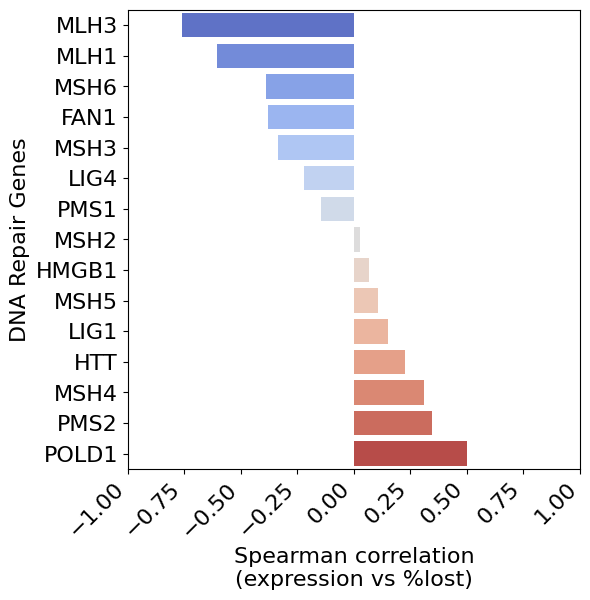

     Gene  Correlation    pvalue
13   MLH3    -0.761765  0.000605
12   MLH1    -0.602941  0.013424
11   MSH6    -0.388235  0.137282
1    FAN1    -0.379412  0.147227
8    MSH3    -0.335294  0.204255
4    LIG4    -0.220588  0.411666
5    PMS1    -0.147059  0.586793
7    MSH2     0.029412  0.913896
2   HMGB1     0.067647  0.803420
10   MSH5     0.108824  0.688288
3    LIG1     0.152941  0.571745
0     HTT     0.226471  0.398983
9    MSH4     0.308824  0.244499
6    PMS2     0.344118  0.191856
14  POLD1     0.500000  0.048580


In [76]:
cor_results = []

for g in dna_repair:
    common_clusters = exp_series.index.intersection(expr_df_neu.index)
    x = expr_df_neu.loc[common_clusters, g]        
    y = exp_series.loc[common_clusters]         
    
    r, p = spearmanr(x, y)
    cor_results.append({'Gene': g, 'Correlation': r, 'pvalue': p})

CTL_cor_df_norm = pd.DataFrame(cor_results).sort_values('Correlation', ascending=True)

plt.figure(figsize=(6,6))
sns.barplot(data=CTL_cor_df_norm, y='Gene', x='Correlation', palette='coolwarm', hue=None)
plt.xticks(rotation=45, ha='right', size=16)
plt.yticks( size=16)
plt.xlabel(f'Spearman correlation\n(expression vs %lost)', fontsize=16)
plt.ylabel('DNA Repair Genes', fontsize=16)
plt.title('', fontsize=20)
plt.tight_layout()
plt.xlim(-1, 1)

#plt.savefig('Figures/F4K.pdf')
plt.show()

print(CTL_cor_df_norm)

In [77]:
##################################################
####  SUPPLEMENTARY FIGURES 14C: DNA repair vs CAG in Excitatory Neurons
##################################################

In [78]:
X_neu_hd = Neurons_HD.X  

expr_raw_neu_hd = pd.DataFrame(X_neu_hd.toarray() if hasattr(X_neu_hd, 'toarray') else X_neu_hd,
                        index=Neurons_HD.obs_names,
                        columns=Neurons_HD.var_names)

expr_raw_neu_hd['cluster'] = Neurons_HD.obs['cluster_names'].values
expr_df_neu_hd = expr_raw_neu_hd.groupby('cluster')[dna_repair].mean()

/var/folders/7p/t1dymgvj689ffh7fbygsmbzc0000gp/T/ipykernel_55460/1362393204.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  expr_df_neu_hd = expr_raw_neu_hd.groupby('cluster')[dna_repair].mean()


/var/folders/7p/t1dymgvj689ffh7fbygsmbzc0000gp/T/ipykernel_55460/3211995085.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  expr_df_neu_hd = expr_raw_neu_hd.groupby('cluster')[dna_repair].mean()
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-pac

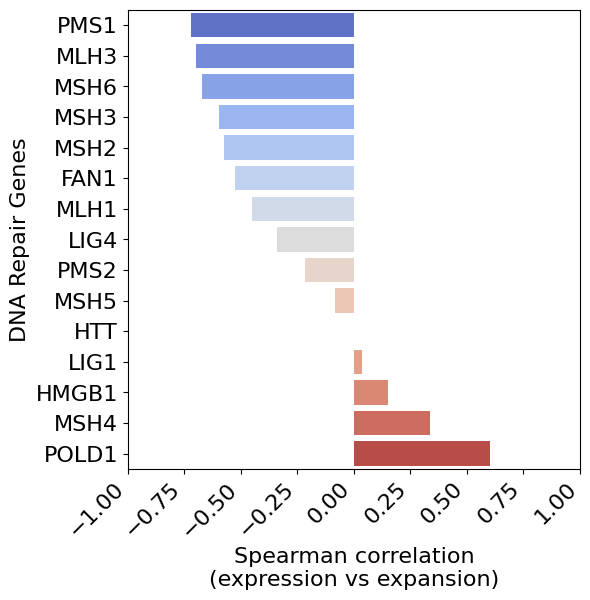

     Gene  Correlation_HD    pvalue
5    PMS1       -0.720588  0.001638
13   MLH3       -0.697059  0.002691
11   MSH6       -0.670588  0.004467
8    MSH3       -0.597059  0.014610
7    MSH2       -0.573529  0.020191
1    FAN1       -0.523529  0.037413
12   MLH1       -0.450000  0.080296
4    LIG4       -0.338235  0.200066
6    PMS2       -0.217647  0.418087
10   MSH5       -0.082353  0.761733
0     HTT        0.000000  1.000000
3    LIG1        0.038235  0.888198
2   HMGB1        0.152941  0.571745
9    MSH4        0.338235  0.200066
14  POLD1        0.600000  0.014007


In [79]:

X_neu_hd = Neurons_HD.X  

expr_raw_neu_hd = pd.DataFrame(X_neu_hd.toarray() if hasattr(X_neu_hd, 'toarray') else X_neu_hd,
                        index=Neurons_HD.obs_names,
                        columns=Neurons_HD.var_names)

expr_raw_neu_hd['cluster'] = Neurons_HD.obs['cluster_names'].values
expr_df_neu_hd = expr_raw_neu_hd.groupby('cluster')[dna_repair].mean()

cor_results = []

for g in dna_repair:
    common_clusters = exp_series.index.intersection(expr_df_neu_hd.index)
    x = expr_df_neu_hd.loc[common_clusters, g]        
    y = exp_series.loc[common_clusters]         
    
    r, p = spearmanr(x, y)
    cor_results.append({'Gene': g, 'Correlation_HD': r, 'pvalue': p})

HD_cor_df_norm = pd.DataFrame(cor_results).sort_values('Correlation_HD', ascending=True)

plt.figure(figsize=(6,6))
sns.barplot(data=HD_cor_df_norm, y='Gene', x='Correlation_HD', palette='coolwarm', hue=None)
plt.xticks(rotation=45, ha='right', size=16)
plt.yticks( size=16)
plt.xlabel(f'Spearman correlation\n(expression vs expansion)', fontsize=16)
plt.ylabel('DNA Repair Genes', fontsize=16)
plt.title('', fontsize=20)
plt.tight_layout()
plt.xlim(-1, 1)

plt.savefig('Figures/SF14C.pdf')
plt.show()

print(HD_cor_df_norm)

In [80]:
##################################################
####  SUPPLEMENTARY FIGURES 14D: DNA repair vs CAG in Excitatory Neurons
##################################################

In [81]:
merge_dna_repair = CTL_cor_df_norm.merge(HD_cor_df_norm, on = 'Gene' ,how='inner')
merge_dna_repair

,Gene,Correlation,pvalue_x,Correlation_HD,pvalue_y
0,MLH3,-0.761765,0.000605,-0.697059,0.002691
1,MLH1,-0.602941,0.013424,-0.450000,0.080296
2,MSH6,-0.388235,0.137282,-0.670588,0.004467
3,FAN1,-0.379412,0.147227,-0.523529,0.037413
4,MSH3,-0.335294,0.204255,-0.597059,0.014610
5,LIG4,-0.220588,0.411666,-0.338235,0.200066
6,PMS1,-0.147059,0.586793,-0.720588,0.001638
7,MSH2,0.029412,0.913896,-0.573529,0.020191
8,HMGB1,0.067647,0.803420,0.152941,0.571745
9,MSH5,0.108824,0.688288,-0.082353,0.761733


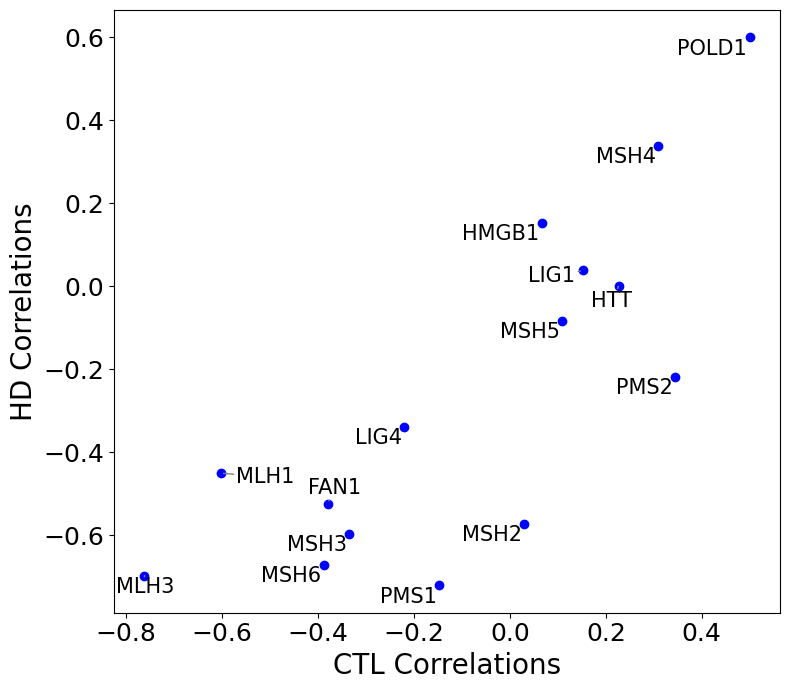

Linear Regression Coefficients:
Slope (Coefficient of Percent Lost): 0.8901489422382869
Intercept: -0.18430871461669002
R-squared: 0.6391126268059371
Pearson r: 0.799, p = 0.0003


In [82]:
X = merge_dna_repair[['Correlation']] 
y = merge_dna_repair['Correlation_HD']  

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

plt.figure(figsize=(8, 7))
plt.scatter(X, y, color='blue', label='Data')

texts = []
for i, row in merge_dna_repair.iterrows():
    texts.append(plt.text(row['Correlation'], row['Correlation_HD'], row['Gene'], fontsize=15))
adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray'))

r, p = pearsonr(X.values.ravel(), y.values.ravel())

plt.xlabel('CTL Correlations', size=20)
plt.ylabel('HD Correlations', size=20)
plt.yticks(size=18)
plt.xticks(size=18)
#plt.ylim(0,10)
plt.title('')
plt.tight_layout()
plt.grid(False)
plt.savefig('Figures/SF14D.pdf', dpi=300, bbox_inches='tight')
plt.show()

print(f'Linear Regression Coefficients:')
print(f'Slope (Coefficient of Percent Lost): {model.coef_[0]}')
print(f'Intercept: {model.intercept_}')
print(f'R-squared: {model.score(X, y)}')
print(f"Pearson r: {r:.3f}, p = {p:.4f}")



In [83]:
##################################################
#### SUPPLEMENTARY FIGURE 14B: DNA repair machinery expression in Allen Brain Atlas (ABA)
##################################################

In [84]:
counts = sc.read_h5ad('../../SEAAD_PFC/SEAAD_A9_RNAseq_final-nuclei.2024-02-13.h5ad')

In [85]:
counts.obs['Neurotypical reference'] = counts.obs['Neurotypical reference'].astype(str).map({'True': True, 'False': False})

In [86]:
CTL=counts[counts.obs['Neurotypical reference']==True].copy()
Neuron = CTL[CTL.obs['Class']!='Non-neuronal and Non-neural'].copy()

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(

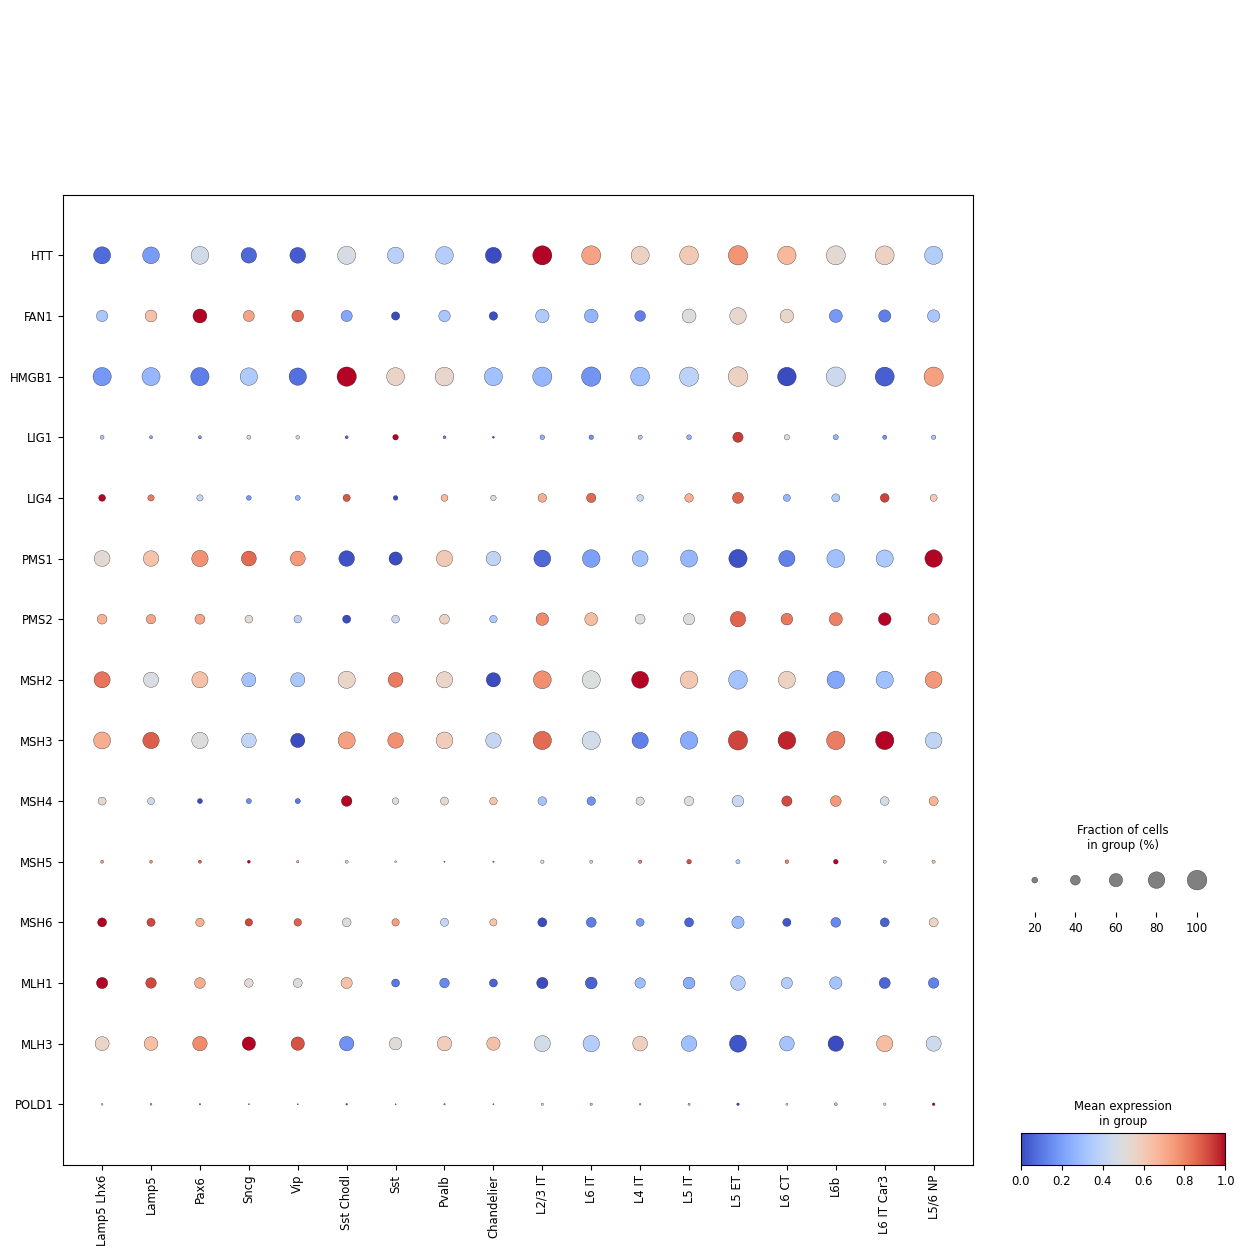

In [87]:
fig, ax = plt.subplots(figsize=(15, 15), facecolor="white")

sc.pl.dotplot(
    Neuron,             
    var_names=dna_repair,
    groupby='Subclass',   
    standard_scale='var',       
    cmap='coolwarm',             
    ax=ax,                      
    swap_axes=True             
)

In [88]:
##################################################
####  SUPPLEMENTARY FIGURES 14E: DNA repair vs CAG in Excitatory Neurons
##################################################

In [89]:
ENuerons=adata[adata.obs['cluster_general'].isin(['Excitatory Neurons'])].copy()
ENeurons_CTL=ENuerons[ENuerons.obs['HD']==False].copy()

In [90]:
cluster_order_eneu = [ "L2.IT", "L3.IT", "L4.IT",'L5.IT', 'L5.ET',"L5.6.NP",'L6.IT','L6.Car3', "L6.CT",'L6b' ]

In [91]:
dna_repair = ['HTT','FAN1', 
'HMGB1', 'LIG1',  'LIG4', 'PMS1','PMS2','MSH2','MSH3','MSH4','MSH5', 
'MSH6', 'MLH1','MLH3','POLD1']

ENeurons_CTL.obs['cluster_names'] = pd.Categorical(
    ENeurons_CTL.obs['cluster_names'],
    categories=cluster_order_eneu,
    ordered=True
)

In [92]:
X_eneu = ENeurons_CTL.X

expr_eneu = pd.DataFrame(X_eneu.toarray() if hasattr(X_eneu, 'toarray') else X_eneu,
                        index=ENeurons_CTL.obs_names,
                        columns=ENeurons_CTL.var_names)

expr_eneu['cluster'] = ENeurons_CTL.obs['cluster_names'].values
expr_df_eneu = expr_eneu.groupby('cluster')[dna_repair].mean()

/var/folders/7p/t1dymgvj689ffh7fbygsmbzc0000gp/T/ipykernel_55460/1172351166.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  expr_df_eneu = expr_eneu.groupby('cluster')[dna_repair].mean()


In [93]:
summary_df_hd = summary_df_hd.set_index('cluster_names')
exp_series = summary_df_hd['mean_with_exp']

KeyError: "None of ['cluster_names'] are in the columns"

In [ ]:
eneu_cor_results = []

for g in dna_repair:
    common_clusters = exp_series.index.intersection(expr_df_eneu.index)
    x = expr_df_eneu.loc[common_clusters, g]        
    y = exp_series.loc[common_clusters]         
    
    r, p = spearmanr(x, y)
    eneu_cor_results.append({'Gene': g, 'Correlation': r, 'pvalue': p})

eneu_cor_df = pd.DataFrame(eneu_cor_results).sort_values('Correlation', ascending=True)

In [ ]:
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests

eneu_cor_results = []

for g in dna_repair:
    if g not in expr_df_eneu.columns:
        continue
        
    common_clusters = exp_series.index.intersection(expr_df_eneu.index)
    x = expr_df_eneu.loc[common_clusters, g]        
    y = exp_series.loc[common_clusters]         
    
    r, p = spearmanr(x, y)
    eneu_cor_results.append({'Gene': g, 'Correlation': r, 'pvalue': p})

eneu_cor_df = pd.DataFrame(eneu_cor_results)

if not eneu_cor_df.empty:
    reject, pvals_adj, _, _ = multipletests(eneu_cor_df['pvalue'], 
                                            alpha=0.05, 
                                            method='fdr_bh')
    
    eneu_cor_df['p_adj'] = pvals_adj
    eneu_cor_df['is_significant'] = reject

# Sort by Correlation
eneu_cor_df = eneu_cor_df.sort_values('Correlation', ascending=True)

In [ ]:
for g in dna_repair:
    common_clusters = expr_df_eneu.index.intersection(exp_series.index)
    x = expr_df_eneu.loc[common_clusters, g]
    y = exp_series.loc[common_clusters]
    
    r, p = spearmanr(x, y)
    
    plt.figure(figsize=(6, 7))
    sns.regplot(x=x.values, y=y.values, scatter_kws={'s': 10, 'color': 'black'},line_kws={'color': 'red'})
    
    texts = []
    for i, c in enumerate(common_clusters):
        texts.append(plt.text(x.iloc[i], y.iloc[i], c, fontsize=15))
    
    adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray'))
    
    plt.title(f'% CAG vs. {g}\nSpearman r = {r:.2f}, p = {p:.3f}', fontsize=20)
    plt.ylabel('% CAG Expansion', fontsize=20)
    plt.xlabel(f'{g} Mean Expression', fontsize=20)
    plt.xticks(fontsize=20, rotation = 35, ha='right')
    plt.yticks(fontsize=20)
    plt.grid(False)
    plt.tight_layout()
    plt.show()